In [24]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
import joblib
import mlflow
import mlflow.sklearn
from sklearn.pipeline import Pipeline
import seaborn as sns
from src.selection_visualization import plot_lasso_vs_et

from src.split_visualization import plot_dst_split_distribution

from src.estimators import NaivePersistence, DirectARBaseline, XGBoostDst, LightGBMDst
from src.evaluate         import compute_metrics
from src.runner           import fit_model, log_metrics_run, print_horizon_metrics, run_segment
from src.mlflow_tracking  import setup_mlflow

In [25]:
setup_mlflow()

<Experiment: artifact_location='file:///C:/Temp/python-start/work/PracticalProjects/cosmic-ray-storm/notebooks/../mlruns/292621262165687921', creation_time=1782395978156, effective_trace_archival_retention=None, experiment_id='292621262165687921', last_update_time=1782395978156, lifecycle_stage='active', name='cosmic_ray_storm_prediction', tags={}, trace_location=None, workspace='default'>

# Cosmic Ray Storm Prediction — Machine Learning

The first part, `cosmic_ray_storm_prediction_EDA.ipynb`, established the physical motivation, statistical properties of the datasets, and formulated the forecasting problem. The present notebook develops and evaluates the corresponding machine learning solution.

# Cosmic Ray Storm Prediction — Machine Learning

The first part, `cosmic_ray_storm_prediction_EDA.ipynb`, established the physical motivation, statistical properties of the datasets, and formulated the forecasting problem. The present notebook addresses the problem formulation through a structured machine learning workflow.

## Introduction

The exploratory analysis established the physical and statistical foundations of the forecasting task, while the **Problem Formulation** defined:

- the forecasting task,
- the candidate forecasting horizons,
- the research objective,
- and the evaluation protocol.

The purpose of this notebook is to implement and experimentally validate this formulation. Rather than constructing the final forecasting model directly, the modelling process is organised as a sequence of dependent stages, each resolving one part of the problem before providing the inputs required by the next stage.

The workflow consists of the following stages:

- **Feature Engineering** – constructs the supervised learning dataset required by the forecasting task.
- **Feature Screening** – identifies the predictor subset used throughout the subsequent experiments.
- **Experimental Design** – defines the forecasting models and validation protocol used to address the problem formulation.
- **Scientific Validation** – establishes the forecasting baselines, evaluates the contribution of neutron-monitor observations with respect to the research objective, and determines the operational forecasting horizon.
- **Operational Forecasting Model** – implements the conclusions of the previous stages to construct and evaluate the final forecasting model.

Throughout the study, all preprocessing, model training, and evaluation follow the same chronological train–validation–test protocol, ensuring a consistent experimental framework across all stages.

## Feature Engineering

This stage addresses the **forecasting task** defined in the Problem Formulation by transforming the consolidated `analysis_data` into a supervised learning dataset suitable for multi-horizon forecasting. The objective is to construct physically meaningful predictors and forecasting targets while preserving the temporal structure required for unbiased model training and evaluation.

Following the CME → solar wind → magnetosphere causal chain, lag horizons are determined by physical constraints—the Burton ring-current decay time `[BUR75]` and the Forbush Decrease precursor interval `[KIS25]`—ensuring that the predictor space remains physically interpretable rather than purely data-driven.

Two types of information leakage are explicitly prevented. Temporal look-ahead leakage is avoided by constructing all lag features exclusively from past observations (`shift(h)`, `h>0`) and by avoiding centred interpolation. Distribution leakage is prevented by estimating all preprocessing parameters exclusively from the training partition before applying them unchanged to the validation and test sets.

In [26]:
# ── Checkpoint — reload analysis_data ──────────────────────────────────────────
# Allows restarting the kernel and running from this cell during Feature
# Engineering / Modeling development, without re-running IDA / EDA.
# If analysis_data is already in memory (e.g. after Run All), it is reused as-is.

if os.path.exists('data/processed/analysis_data.parquet'):
   analysis_data = pd.read_parquet('data/processed/analysis_data.parquet')
   print(f"Checkpoint loaded: {len(analysis_data):,} rows")
else:
   raise RuntimeError("No checkpoint found — run the IDA / Data Preparation cells above first.")

Checkpoint loaded: 364,728 rows


### Target Variable

Target variables are generated immediately after construction of the cleaned feature table and before any temporal split or model training.

The regression target is the $D_{st}$ index shifted $N$ hours into the future:

$$\text{dst\_target}_t = D_{st}(t + N)$$

implemented as `feat['dst'].shift(-N)`. A negative shift places the future value at the current row — at fitting time the model sees only present and past inputs. Five regression targets are constructed for $N \in \{1, 3, 7, 12, 21\}$ hours.

**Leakage note.** The shifted target columns are excluded from the feature matrix before any fitting step. The raw `dst` column is retained as a direct predictor representing the currently observed value, but no shifted target is ever used as an input feature.

In [27]:
# ── Target Variable ──────────────────────────────────────────────────────
feat = analysis_data.copy()

# ── Constants ─────────────────────────────────────────────────────────────────
STORM_THR  = -50                   # nT — moderate-storm threshold (for reference only)
K_HORIZONS = [1, 3, 7, 12, 21]    # forecast horizons: Burton τ≈7-8h, Forbush lead 7-21h


def build_target(df, k):
    """
    Adds regression target for horizon k.

    Parameters
    ----------
    df : DataFrame with a 'dst' column
    k  : int — forecast horizon in hours
    """
    df[f"dst_target_{k}h"] = df["dst"].shift(-k)


print(f"Storm reference   : dst < {STORM_THR} nT")
print(f"Forecast horizons : {K_HORIZONS} h\n")
print(f"{'Horizon':>10} {'NaN':>6} {'Target min':>12} {'Target max':>12}")
print("-" * 44)
for k in K_HORIZONS:
    build_target(feat, k)
    col   = f"dst_target_{k}h"
    n_nan = feat[col].isna().sum()
    print(f"{k:>8}h  {n_nan:>6} {feat[col].min():>12.1f} {feat[col].max():>12.1f}")

Storm reference   : dst < -50 nT
Forecast horizons : [1, 3, 7, 12, 21] h

   Horizon    NaN   Target min   Target max
--------------------------------------------
       1h       1       -589.0         81.0
       3h       3       -589.0         81.0
       7h       7       -589.0         81.0
      12h      12       -589.0         81.0
      21h      21       -589.0         81.0


> **Observations — Target Variable:**
> - Five regression target columns (`dst_target_{1,3,7,12,21}h`) were generated, corresponding to the predefined forecasting horizons.
> - The number of missing values introduced by `shift(-k)` equals the forecast horizon (1, 3, 7, 12 and 21 samples respectively), confirming the expected target alignment.
> - All target columns preserve the original $D_{st}$ range (−589 to 81 nT), indicating that shifting changes only the temporal alignment and not the underlying value distribution.
> - The terminal rows containing undefined future targets are removed during the subsequent preprocessing stage before model fitting.

### Derived Features

Derived features are constructed from the original measurements to capture changes over time and relationships that are not directly visible in the raw data. All features use only information available at or before the forecast time.

| Feature | Transformation | Purpose |
|---|---|---|
| `d_neutron` | Relative first difference | Relative neutron flux change |
| `bz_acc_3h` | Rolling sum (3h) | Short-term southward IMF persistence |
| `bz_acc_6h` | Rolling sum (6h) | Medium-term southward IMF persistence |
| `bz_acc_12h` | Rolling sum (12h) | Long-term southward IMF persistence |
| `dbz_dt` | First difference | Hourly IMF change rate |

> **Note.** The OMNI dataset already includes the interplanetary electric field (`e_field`). Since this quantity is provided directly, no additional interaction feature is constructed.

#### Differential neutron flux (`d_neutron`)

The raw neutron count changes slowly over time. This feature measures the relative hourly change instead, making sudden decreases easier for the model to detect:

$$\delta n_t = \frac{N_t - N_{t-1}}{N_{t-1}}$$

The feature `d_neutron` is the implementation of the differential neutron flux $\delta n(t)$ introduced in the Problem Formulation. Here, the differencing window is fixed to $w = 1$ hour. The differencing window defines how the neutron signal is transformed and is independent of the forecasting horizon.

#### Accumulated southward $B_z$ (`bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h`)

A single negative value of $B_z$ is usually not enough to produce a storm. These rolling sums measure how long southward $B_z$ conditions persist:

$$\text{bz\_acc}_{w,t} = \sum_{k=0}^{w-1} B_{z,\,t-k}$$

#### IMF rotation rate (`dbz_dt`)

While the accumulated $B_z$ features measure persistence, `dbz_dt` measures how quickly the magnetic field changes from one hour to the next:

$$dbz\_dt_t = B_{z,t} - B_{z,t-1}$$

In [28]:
# ── Derived Features ─────────────────────────────────────────────────────

# Differential neutron flux
feat["d_neutron"] = (
    feat["neutron_counts"].diff() / feat["neutron_counts"].shift(1)
)

# Accumulated southward Bz
bz_south = feat["bz_gsm"].clip(upper=0)

for window in [3, 6, 12]:
    feat[f"bz_acc_{window}h"] = bz_south.rolling(window).sum()

# IMF rotation rate
feat["dbz_dt"] = feat["bz_gsm"].diff()

derived_cols = ["d_neutron", "bz_acc_3h", "bz_acc_6h", "bz_acc_12h", "dbz_dt"]

print(f"{'Feature':>15} {'NaN':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 65)
for col in derived_cols:
    s = feat[col]
    print(f"{col:>15} {s.isna().sum():>8} {s.mean():>10.3f} {s.std():>10.3f} {s.min():>10.3f} {s.max():>10.3f}")

        Feature      NaN       Mean        Std        Min        Max
-----------------------------------------------------------------
      d_neutron       26      0.000      0.004     -0.247      1.449
      bz_acc_3h    73555     -3.192      5.008   -145.400      0.000
      bz_acc_6h    83627     -6.361      8.973   -250.800      0.000
     bz_acc_12h    97058    -12.679     15.607   -363.600      0.000
         dbz_dt    69379     -0.000      2.268    -53.900     55.700


> **Observations — Derived Features:**
> - `d_neutron` contains 26 NaN values, inherited from missing `neutron_counts` and the first-order differencing operation. The feature is centred around zero with occasional large positive and negative changes corresponding to rapid variations in the neutron count rate.
> - The number of missing values in `bz_acc_{3,6,12}h` increases with the rolling window length, as expected. Because only southward ($B_z \leq 0$) values are accumulated, the maximum value is 0 for all three features.
> - `dbz_dt` inherits missing values from `bz_gsm`. Its mean is close to zero, indicating no systematic bias in the hourly changes of the IMF.
> - Missing values in the derived features are inherited from the source variables or introduced by the expected behaviour of the `diff()` and `rolling()` operations. No unexpected missing values are created during feature construction.

### Lag Features

Lag features give the model access to recent history instead of only the current value at time tt. This is useful because geomagnetic storms develop over several hours, and the recent behaviour of the input variables can be more informative than a single instantaneous observation.

Lag features are created for `bz_gsm`, `sw_speed`, and `neutron_counts` — the three key variables describing the solar wind–magnetosphere interaction. The same lag horizons are used throughout the forecasting framework: 1, 3, 7, 12 and 21 hours.

All lag features are constructed using positive `shift()` values, ensuring that only past observations are available to the model.

In [29]:
# ── Lag Features ─────────────────────────────────────────────────────────

LAG_COLS     = ["bz_gsm", "neutron_counts", "sw_speed"]
LAG_HORIZONS = [1, 3, 7, 12, 21]

for col in LAG_COLS:
    for lag in LAG_HORIZONS:
        feat[f"{col}_lag{lag}"] = feat[col].shift(lag)

lag_cols = [c for c in feat.columns if "_lag" in c]

print(f"{'Feature':>25} {'NaN':>8} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 75)
for col in lag_cols:
    s = feat[col]
    print(f"{col:>25} {s.isna().sum():>8} {s.mean():>10.3f} {s.std():>10.3f} {s.min():>10.3f} {s.max():>10.3f}")

                  Feature      NaN       Mean        Std        Min        Max
---------------------------------------------------------------------------
              bz_gsm_lag1    64683     -0.022      3.074    -57.800     41.600
              bz_gsm_lag3    64685     -0.022      3.074    -57.800     41.600
              bz_gsm_lag7    64689     -0.022      3.074    -57.800     41.600
             bz_gsm_lag12    64694     -0.022      3.074    -57.800     41.600
             bz_gsm_lag21    64703     -0.022      3.074    -57.800     41.600
      neutron_counts_lag1       25     94.507      6.068     59.889    220.656
      neutron_counts_lag3       27     94.507      6.068     59.889    220.656
      neutron_counts_lag7       31     94.507      6.068     59.889    220.656
     neutron_counts_lag12       36     94.507      6.068     59.889    220.656
     neutron_counts_lag21       45     94.507      6.068     59.889    220.656
            sw_speed_lag1    68682    431.723    101.94

> **Observations — Lag Features:**
> - Fifteen lag features were generated from three variables (`bz_gsm`, `sw_speed`, and `neutron_counts`) using five lag horizons.
> - Summary statistics remain nearly unchanged across lag horizons because lagging shifts observations in time without altering their underlying distribution.
> - Missing values increase with the lag horizon. The first $k$ rows of each lagged feature are undefined, while additional missing values are inherited from the original variables.
> - The largest number of missing values occurs for `sw_speed` and `bz_gsm`, reflecting gaps already present in the OMNI dataset rather than the lagging process itself.
> - The additional missing values introduced by each lag equal the applied lag length, confirming the correct behaviour of `shift()` and ensuring that no future information is used.

### Cyclical Encoding of the Solar Cycle Phase

The phase of the approximately 11-year solar cycle provides long-term context for solar activity and geomagnetic storm occurrence. Because the cycle is periodic, a linear representation would introduce an artificial discontinuity at each cycle boundary — for example, phases 0.99 and 0.01 are numerically far apart but physically adjacent.

To preserve this continuity, the fractional cycle phase $\phi \in [0, 1)$ is represented using sine and cosine transformations:

solar\_sin=sin(2πϕ),solar\_cos=cos(2πϕ)\text{solar\_sin} = \sin(2\pi\phi), \qquad \text{solar\_cos} = \cos(2\pi\phi)

Using both sine and cosine provides a unique representation of the cycle phase while preserving its periodic nature.

Solar cycle boundaries follow the definitions reported in Ishkov (2009) `[ISH09]`.

In [30]:
# ── Cyclical Encoding of the Solar Cycle Phase ───────────────────────────
# Solar cycle boundaries are approximate cycle minima from Ishkov (2009) [ISH09].
# The end of Cycle 25 is projected and used only to compute phase values
# for dates after 2019-12.

CYCLE_BOUNDARIES = [
    pd.Timestamp("1976-03-01"),
    pd.Timestamp("1986-09-01"),
    pd.Timestamp("1996-06-01"),
    pd.Timestamp("2008-12-01"),
    pd.Timestamp("2019-12-01"),
    pd.Timestamp("2030-01-01"),  # Cycle 25 end — approximate projection
]

def solar_cycle_phase(timestamps, boundaries):
    """
    Return fractional phase in [0, 1) within the current solar cycle.
    Phase 0 corresponds to cycle minimum; phase approaches 1 near the next minimum.
    """
    phase = np.full(len(timestamps), np.nan)
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        mask = (timestamps >= start) & (timestamps < end)
        duration = (end - start).total_seconds()
        elapsed  = (timestamps[mask] - start).total_seconds()
        phase[mask] = elapsed / duration
    return phase

feat["solar_cycle_phase"] = solar_cycle_phase(
    pd.DatetimeIndex(feat["datetime"]),
    CYCLE_BOUNDARIES,
)
feat["solar_sin"] = np.sin(2 * np.pi * feat["solar_cycle_phase"])
feat["solar_cos"] = np.cos(2 * np.pi * feat["solar_cycle_phase"])

# solar_cycle_phase is an intermediate variable — excluded from the feature matrix
feat = feat.drop(columns=["solar_cycle_phase"])

print(f"{'Column':>20} {'NaN':>6} {'Min':>8} {'Max':>8}")
print("-" * 45)
for col in ["solar_sin", "solar_cos"]:
    s = feat[col]
    print(f"{col:>20} {s.isna().sum():>6} {s.min():>8.4f} {s.max():>8.4f}")

              Column    NaN      Min      Max
---------------------------------------------
           solar_sin      0  -1.0000   1.0000
           solar_cos      0  -1.0000   1.0000


> **Observations — Cyclical Encoding:**
> - The solar cycle phase was encoded using two features: `solar_sin` and `solar_cos`.
> - Both features are bounded within [−1, 1], as expected from sine and cosine transformations.
> - No missing values were introduced by the transformation.
> - The intermediate `solar_cycle_phase` column was removed after encoding and is not used as a model input.

### Final Feature Matrix

All engineered features are collected into a single predictor matrix. The table below summarises the full feature set with the physical motivation for each group.

`pf_10mev`, `pf_30mev`, `pf_60mev` are excluded on two grounds established in the Proton Flux Contamination Masking step: GOES proton flux at geosynchronous orbit does not reliably represent the true interplanetary SEP flux below $P_{dyn}$ < 10 nPa `[ROD14]`, and no reference Dst prediction model uses proton flux as a predictor `[HU23]` `[NAI23]` `[CAM19]`.

| Group | Features | Count | Physical basis |
|---|---|---|---|
| Direct — IMF | `bz_gsm` | 1 | Primary driver of ring current injection `[BUR75]` |
| Direct — Solar Wind | `sw_speed`, `sw_density`, `sw_pressure`, `sw_temp`, `e_field`, `plasma_beta`, `mach_alfven` | 7 | Solar wind state at L1 |
| Direct — LMKS | `neutron_counts` | 1 | Galactic cosmic ray flux — Forbush Decrease precursor `[KIS25]` |
| Direct — Solar | `f107`, `ssn` | 2 | Solar activity level |
| Derived | `d_neutron`, `dbz_dt`, `bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h` | 5 | Explicit physical signals — Section 5.2 |
| Lag | `bz_gsm_lag{1,3,7,12,21}`, `neutron_counts_lag{1,3,7,12,21}`, `sw_speed_lag{1,3,7,12,21}` | 15 | Temporal history — Section 5.3 |
| Cyclical | `solar_sin`, `solar_cos` | 2 | 11-year solar cycle phase — Section 5.4 |
| **Total** | | **33** | |

In [31]:
# ── Final Feature Matrix ──────────────────────────────────────────────────
# sw_pressure excluded from lags: ρV² is a function of sw_density and sw_speed
#   — lag information already captured by sw_speed lags.
# sw_temp excluded from lags: weak predictor (low correlation with dst in EDA).
# plasma_beta and mach_alfven included without lags: moderate correlation with
#   dst (r≈-0.32, r≈-0.56); capture magnetospheric state independently of bz_gsm.
#   LASSO will penalise if redundant.
# pf_10/30/60mev excluded: GOES proton flux at geosynchronous orbit is unreliable
#   below Pdyn < 10 nPa due to geomagnetic cutoffs [ROD14] — even flag=0 values
#   do not represent true interplanetary SEP flux. No reference model uses proton
#   flux as a Dst predictor.

FEATURE_COLS = [
    # Direct — IMF
    "bz_gsm",
    # Direct — Solar Wind
    "sw_speed", "sw_density", "sw_pressure", "sw_temp",
    "e_field", "plasma_beta", "mach_alfven",
    # Direct — Solar
    "f107", "ssn",
    # Direct — Neutron Monitor
    "neutron_counts",
    # Derived
    "d_neutron", "dbz_dt",
    "bz_acc_3h", "bz_acc_6h", "bz_acc_12h",
    # Lag — IMF
    "bz_gsm_lag1", "bz_gsm_lag3", "bz_gsm_lag7",
    "bz_gsm_lag12", "bz_gsm_lag21",
    # Lag — Solar Wind
    "sw_speed_lag1", "sw_speed_lag3", "sw_speed_lag7",
    "sw_speed_lag12", "sw_speed_lag21",
    # Lag — Neutron
    "neutron_counts_lag1", "neutron_counts_lag3", "neutron_counts_lag7",
    "neutron_counts_lag12", "neutron_counts_lag21",
    # Cyclical
    "solar_sin", "solar_cos",
]

print(f"Total features : {len(FEATURE_COLS)}")

missing = [c for c in FEATURE_COLS if c not in feat.columns]
print(f"Missing        : {missing if missing else 'none'}")

coverage = feat[FEATURE_COLS].notna().mean().sort_values()
print(f"\nFeature coverage (ascending):")
print(coverage.to_string())

Total features : 33
Missing        : none

Feature coverage (ascending):
bz_acc_12h              0.733889
bz_acc_6h               0.770714
plasma_beta             0.782786
sw_temp                 0.787872
mach_alfven             0.792662
bz_acc_3h               0.798329
sw_pressure             0.798820
sw_density              0.798842
e_field                 0.805463
dbz_dt                  0.809779
sw_speed_lag21          0.811635
sw_speed_lag12          0.811660
sw_speed_lag7           0.811673
sw_speed_lag3           0.811684
sw_speed_lag1           0.811690
sw_speed                0.811693
bz_gsm_lag21            0.822599
bz_gsm_lag12            0.822624
bz_gsm_lag7             0.822638
bz_gsm_lag3             0.822649
bz_gsm_lag1             0.822654
bz_gsm                  0.822657
f107                    0.999145
neutron_counts_lag21    0.999877
neutron_counts_lag12    0.999901
neutron_counts_lag7     0.999915
neutron_counts_lag3     0.999926
d_neutron               0.999929
neu

> **Observations — Final Feature Matrix:**
>
> * The final predictor matrix contains 33 features, and all selected predictors are available in the dataset.
> * Three levels of feature completeness are observed:
>
>   * **73–82%** — IMF, solar wind, and derived features. Missing values are inherited from the OMNI dataset, with `bz_acc_12h` showing the lowest completeness (73.4%) because the rolling accumulation requires 12 consecutive valid `bz_gsm` observations.
>   * **~99%** — neutron monitor features, reflecting only 24 missing hourly observations over the 42-year study period `[KIS25]`.
>   * **100%** — `ssn`, `solar_sin`, and `solar_cos`.
> * The GOES proton flux variables (`pf_10mev`, `pf_30mev`, and `pf_60mev`) are excluded from the predictor matrix because of their limited coverage (61.6% after contamination masking) and the lack of a justified physical role in established $D_{st}$ forecasting models.
> * Missing values are intentionally preserved at this stage. Imputation is performed after the train/validation/test split to prevent information leakage from statistics computed on the full dataset.


## Experimental Design

This stage addresses the **evaluation objective** defined in the Problem Formulation by establishing a common experimental protocol for all forecasting models. Rather than comparing different data preparation strategies, every subsequent experiment uses the same temporal split, preprocessing pipeline, and evaluation procedure. This ensures that any observed performance differences can be attributed to the forecasting models and predictor sets rather than to differences in data handling.

The forecasting horizons have already been defined during target construction. The focus here is on the chronological train–validation–test split, missing-value treatment, feature scaling, and the reusable modelling artifacts required by the subsequent Feature Screening and Scientific Validation stages.

A fundamental principle throughout the study is that every operation estimating parameters from data is fitted exclusively on the training partition. The learned transformations are then applied unchanged to the validation and test segments, preventing information leakage and ensuring a fair comparison between all forecasting models.

### Train / Validation / Test Split

The dataset is partitioned into six chronological segments for model development and evaluation. Three design principles govern the split.

**Arrow of time.** Lag features reference past values at horizons up to 21 hours. A random or shuffled split would allow observations from the same storm sequence to appear in both training and evaluation data, introducing look-ahead leakage through the lag features. All segments are strictly chronological.

**Solar cycle variability.** Geomagnetic storm occurrence changes systematically over the solar cycle. The training period spans more than one complete cycle, while the validation and test segments represent different activity levels, allowing the models to be evaluated under distribution shift.

**Purge zones.** At each internal segment boundary, 21 hours of data are excluded from both sides — equal to the maximum lag horizon. Without purging, lag features near a segment boundary could reference observations from the preceding segment, introducing cross-segment leakage `[LAP20]`.

**Pre-1995 exclusion.** The survivability audit in the EDA notebook showed that observations before 1995 contain persistent structural gaps caused by earlier geocentric spacecraft. After feature construction only a small fraction of these data remains usable, so pre-1995 observations are excluded from all modelling stages and discussed as a study limitation.

**Segment design:**

| Segment | Period | Physical content |
|---|---|---|
| Train\_1 | 1995-01-01 – 2003-10-14 | Solar Cycles 22–23, ascending + maximum |
| Val\_Storm | 2003-10-15 – 2003-12-15 | Halloween + November 2003 superstorm ($D_{st}$ = −422 nT) |
| Train\_2 | 2003-12-16 – 2008-12-31 | Solar Cycle 23, declining phase |
| Val\_Main | 2009-01-01 – 2014-12-31 | Early–mid Solar Cycle 24 |
| Test\_Active | 2015-01-01 – 2015-12-31 | St. Patrick's Day + June 2015 storms |
| Test\_Quiet | 2016-01-01 – 2023-07-10 | Declining Cycle 24 + Cycle 25 |

Val\_Storm is carved from the training window rather than appended after it, following the strategy of Nair et al. `[NAI23]` to ensure that an extreme storm period is available for dedicated evaluation.

Hyperparameter selection uses Val\_Main only. Val\_Storm is reserved for post-selection storm diagnostics, while the test segments are evaluated once after all modelling decisions have been finalised `[CAM19]`.

The figure below reproduces the analysis of Cristoforetti et al. (2022) `[SCI22]`, illustrating the effects of different data splitting strategies on the $D_{st}$ distribution.

* **(a) Chronological split** — validation and test sets follow the training period in time. Because Solar Cycle 24 is considerably weaker than Solar Cycles 22–23, the storm tail ($D_{st} < -100$ nT) is less represented in the validation and test data than in the training set.
* **(b) Random split** — all three subsets follow nearly identical distributions because observations are sampled from the full record. Although desirable for i.i.d. machine learning, this strategy is inappropriate for time series with lag features because it introduces look-ahead leakage.
* **(c) Inverse-frequency weighting** — illustrates one approach for compensating the imbalance created by the chronological split by assigning higher importance to rare storm observations during training.

This project adopts the chronological split (panel a) to preserve the temporal order of observations. The resulting imbalance between quiet and storm conditions is addressed later through storm sample weighting during model training.


Saved: images/fig_dst_split_distribution.png


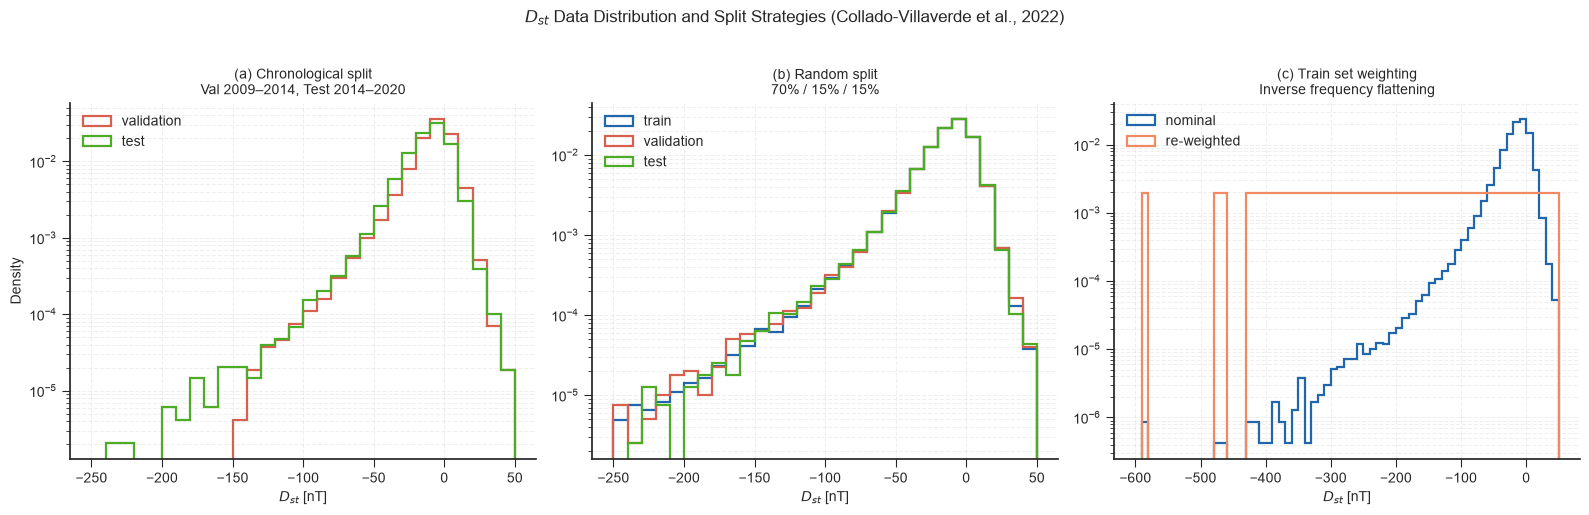

In [32]:

plot_dst_split_distribution(
    save_path='images/fig_dst_split_distribution.png'
)

Because geomagnetic storm occurrence varies across the solar cycle, a chronological split produces different Dst distributions in the training and evaluation periods. In particular, the storm tail is less represented in the validation and test segments than in the training data. This distributional mismatch is illustrated in Figure `Dst Data Distribution and Split Strategies (Collado-Villaverde et al., 2022)` and motivates the use of storm sample weighting during model training.

> **Observations — Train / Validation / Test Split:**
>
> * The chronological split creates a clear distributional mismatch in the storm tail. The training period (1995–2008) includes the active Solar Cycles 22–23, whereas `Val_Main` and `Test_Quiet` correspond largely to the weaker Solar Cycle 24. Consequently, extreme storms ($D_{st} < -100$ nT) are much less frequent in the evaluation segments.
> * `Val_Storm` has the highest storm fraction (13.1%), confirming that the Halloween and November 2003 events are successfully isolated for dedicated storm evaluation.
> * `Test_Quiet` has the lowest storm fraction (1.4%), providing a realistic assessment of model performance under relatively quiet space-weather conditions.
> * The 21-hour purge zones remove only a negligible number of observations while preventing information leakage across segment boundaries.
> * The distributional mismatch introduced by the chronological split motivates the storm-weighting strategy adopted later during model training.


Val_Storm is carved from the training period rather than appended after it, following the evaluation strategy of Nair et al. [NAI23]. This preserves an extreme storm interval for independent assessment while allowing the remaining training data to span the full Solar Cycle 23. The resulting non-contiguous training set (Train_1 and Train_2) is implemented as the union of two chronological intervals separated by a purge zone.

Hyperparameter optimisation uses Val_Main only. Val_Storm is reserved for post-selection storm diagnostics and is never used during parameter tuning. The two test segments (Test_Active and Test_Quiet) are evaluated only once, after all modelling decisions have been finalised [CAM19].

In [33]:
# ── Train / Validation / Test Split ──────────────────────────────────────
# Six chronological segments with 21-hour purge zones.
# Pre-1995 observations are excluded based on the survivability audit.
# Val_Storm is reserved for dedicated storm diagnostics.

PURGE_H = 21

BOUNDARIES = {
    'train1_start':       pd.Timestamp('1995-01-01 00:00'),
    'train1_end':         pd.Timestamp('2003-10-14 23:00'),
    'val_storm_start':    pd.Timestamp('2003-10-15 00:00'),
    'val_storm_end':      pd.Timestamp('2003-12-15 23:00'),
    'train2_start':       pd.Timestamp('2003-12-16 00:00'),
    'train2_end':         pd.Timestamp('2008-12-31 23:00'),
    'val_main_start':     pd.Timestamp('2009-01-01 00:00'),
    'val_main_end':       pd.Timestamp('2014-12-31 23:00'),
    'test_active_start':  pd.Timestamp('2015-01-01 00:00'),
    'test_active_end':    pd.Timestamp('2015-12-31 23:00'),
    'test_quiet_start':   pd.Timestamp('2016-01-01 00:00'),
    'test_quiet_end':     pd.Timestamp('2023-07-10 23:00'),
}

dt = feat['datetime']

def segment_mask(start_key, end_key, purge_start=True, purge_end=True):
    """Returns boolean mask for a segment, with optional purge zones."""
    start = BOUNDARIES[start_key]
    end   = BOUNDARIES[end_key]
    if purge_start:
        start = start + pd.Timedelta(hours=PURGE_H)
    if purge_end:
        end   = end   - pd.Timedelta(hours=PURGE_H)
    return (dt >= start) & (dt <= end)

masks = {
    'train':       segment_mask('train1_start', 'train1_end',
                                purge_start=False, purge_end=True) |
                   segment_mask('train2_start', 'train2_end',
                                purge_start=True,  purge_end=True),
    'val_storm':   segment_mask('val_storm_start',  'val_storm_end'),
    'val_main':    segment_mask('val_main_start',   'val_main_end'),
    'test_active': segment_mask('test_active_start','test_active_end'),
    'test_quiet':  segment_mask('test_quiet_start', 'test_quiet_end',
                                purge_start=True, purge_end=False),
}

print(f"{'Segment':>12} {'Rows':>8} {'% total':>8} {'Storm hrs':>10} {'Storm %':>8}")
print("─" * 52)

assigned = pd.Series(False, index=feat.index)
total_storm = ((feat['dst_target_7h'] < -50) & feat['dst_target_7h'].notna()).sum()

for name, mask in masks.items():
    rows      = mask.sum()
    pct       = 100 * rows / len(feat)
    storm_hrs = ((feat.loc[mask, 'dst_target_7h'] < -50) &
                  feat.loc[mask, 'dst_target_7h'].notna()).sum()
    storm_pct = 100 * storm_hrs / rows if rows > 0 else 0
    print(f"{name:>12} {rows:>8,} {pct:>7.1f}% {storm_hrs:>10,} {storm_pct:>7.1f}%")
    assigned  = assigned | mask

print("─" * 52)
unassigned_mask  = ~assigned
rows_u    = unassigned_mask.sum()
pct_u     = 100 * rows_u / len(feat)
storm_u   = ((feat.loc[unassigned_mask, 'dst_target_7h'] < -50) &
              feat.loc[unassigned_mask, 'dst_target_7h'].notna()).sum()
storm_pct_u = 100 * storm_u / rows_u if rows_u > 0 else 0
print(f"{'unassigned':>12} {rows_u:>8,} {pct_u:>7.1f}% {storm_u:>10,} {storm_pct_u:>7.1f}%")
print("─" * 52)
print(f"{'total':>12} {len(feat):>8,} {'100.0%':>8} {total_storm:>10,}")

     Segment     Rows  % total  Storm hrs  Storm %
────────────────────────────────────────────────────
       train  121,185    33.2%      5,704     4.7%
   val_storm    1,446     0.4%        190    13.1%
    val_main   52,542    14.4%      1,165     2.2%
 test_active    8,718     2.4%        660     7.6%
  test_quiet   65,931    18.1%        932     1.4%
────────────────────────────────────────────────────
  unassigned  114,906    31.5%     10,892     9.5%
────────────────────────────────────────────────────
       total  364,728   100.0%     19,543


> **Observations — Train / Validation / Test Split:**
>
> * The five modelling segments contain 68.5% of the available observations (249,822 rows). The remaining 31.5% correspond primarily to the pre-1995 exclusion and the purge zones at segment boundaries.
> * The assigned segments contain 8,651 of the 19,543 storm hours (44.3%). Most excluded storm observations originate from the pre-1995 period and are treated as a study limitation.
> * `Val_Storm` has the highest storm fraction (13.1%), confirming that the Halloween and November 2003 events are successfully isolated for dedicated storm evaluation.
> * `Test_Quiet` has the lowest storm fraction (1.4%), providing an evaluation period dominated by relatively quiet geomagnetic conditions.
> * The 21-hour purge zones remove only a negligible number of observations while preventing leakage between adjacent segments.


### Missing Data Imputation

Missing values are imputed only after the train/validation/test split. All imputation parameters are estimated from the training data, ensuring that no information from the validation or test periods influences the preprocessing.

Two standard strategies were considered:

* **Forward fill (`ffill`)** preserves temporal continuity by propagating the most recent valid observation. This is appropriate for hourly solar wind measurements but becomes unreliable over long gaps.
* **Median imputation** is robust to outliers and avoids propagating stale values, but it ignores the temporal evolution of the solar wind.

The adopted approach combines both methods. Missing values are first forward-filled with a maximum gap of three hours. Any remaining missing values are then replaced using the median computed from the training set. The three-hour limit is consistent with the characteristic response time of the magnetosphere to changes in the interplanetary magnetic field `[BUR75]`.

Forward fill is applied independently within each dataset segment, ensuring that no values propagate across train, validation, or test boundaries.


In [34]:
# ── Imputation ────────────────────────────────────────────────────────────────
# Strategy: ffill (max 3h) within each segment, then median fill for remaining NaN.
# Medians fitted on train only — applied to all segments to prevent leakage.

# Ensure chronological order
feat = feat.sort_values('datetime').reset_index(drop=True)
dt   = feat['datetime']

# Recompute masks after sort
masks = {
    'train':       segment_mask('train1_start', 'train1_end',
                                purge_start=False, purge_end=True) |
                   segment_mask('train2_start', 'train2_end',
                                purge_start=True,  purge_end=True),
    'val_storm':   segment_mask('val_storm_start',  'val_storm_end'),
    'val_main':    segment_mask('val_main_start',   'val_main_end'),
    'test_active': segment_mask('test_active_start','test_active_end'),
    'test_quiet':  segment_mask('test_quiet_start', 'test_quiet_end',
                                purge_start=True, purge_end=False),
}

# Compute medians on train only
train_medians = feat.loc[masks['train'], FEATURE_COLS].median()
n_nan_medians = train_medians.isna().sum()
print(f"NaN in train medians : {n_nan_medians}")
if n_nan_medians > 0:
    print(train_medians[train_medians.isna()])

def impute_segment(df, mask, medians, ffill_limit=3):
    """
    Impute NaN values in FEATURE_COLS within one segment only:
    1. Forward-fill up to ffill_limit consecutive hours.
    2. Fill remaining NaN values with training-set medians.

    The segment is copied before imputation, so forward-fill cannot cross
    train/validation/test boundaries.
    """
    seg = df.loc[mask, FEATURE_COLS].copy()
    seg = seg.ffill(limit=ffill_limit)
    seg = seg.fillna(medians)
    df.loc[mask, FEATURE_COLS] = seg

# Impute all segments
for name, mask in masks.items():
    impute_segment(feat, mask, train_medians, ffill_limit=3)

# Verify
print(f"\n{'Segment':>12} {'NaN remaining':>15}")
print("─" * 30)
for name, mask in masks.items():
    n_nan = feat.loc[mask, FEATURE_COLS].isna().sum().sum()
    print(f"{name:>12} {n_nan:>15,}")

NaN in train medians : 0

     Segment   NaN remaining
──────────────────────────────
       train               0
   val_storm               0
    val_main               0
 test_active               0
  test_quiet               0


> **Observations — Imputation:**
> - Training-set medians contain no missing values, so all 33 features have a valid fallback value.
> - After hybrid imputation (`ffill` up to 3 hours + training median fill), no missing values remain in any modelling segment.
> - Forward fill is applied independently within each segment, preventing values from propagating across train, validation, or test boundaries.
> - Median values are fitted on the training segment only and then applied to `val_storm`, `val_main`, `test_active`, and `test_quiet`, preventing distribution leakage from future periods.

### Saving Feature Engineering Artifacts

The outputs of the feature engineering stage are saved for reuse in the subsequent notebooks. Persisting these artifacts avoids repeating preprocessing and guarantees that feature selection, hyperparameter optimisation, and model evaluation all use an identical experimental setup.

Three artifacts are exported:

- **Split masks (`masks`)** — Boolean index arrays defining the training, validation, and test segments.
- **Imputed feature matrix (`feat_split.parquet`)** — the complete feature matrix after feature engineering and imputation. The data remain **unscaled**; any model-specific scaling is performed later.
- **Project constants (`context_constants.pkl`)** — shared configuration values used throughout the project:
  - `FEATURE_COLS` — names of the 33 predictor variables;
  - `K_HORIZONS` — forecast horizons (1, 3, 7, 12, and 21 hours);
  - `STORM_THR` — Dst threshold defining storm conditions;
  - `PURGE_H` — purge width (21 hours) used at segment boundaries;
  - `BOUNDARIES` — timestamps defining the train, validation, and test intervals.

In [35]:
# ── Save Feature Engineering Artifacts ───────────────────────────────────
# Persist the outputs of Feature Engineering for downstream notebooks.

# 1. Split masks — boolean masks for each segment
joblib.dump(masks, 'models/split_masks.pkl')
print("Saved: models/split_masks.pkl")

# 2. Imputed feature matrix (unscaled)
feat.to_parquet('data/processed/feat_split.parquet')
print(f"Saved: data/processed/feat_split.parquet  ({len(feat):,} rows, {feat.shape[1]} columns)")

# 3. Constants from this notebook
joblib.dump({
    'FEATURE_COLS' : FEATURE_COLS,
    'K_HORIZONS'   : K_HORIZONS,
    'STORM_THR'    : STORM_THR,
    'PURGE_H'      : PURGE_H,
    'BOUNDARIES'   : BOUNDARIES,
}, 'models/context_constants.pkl')
print("Saved: models/context_constants.pkl")

Saved: models/split_masks.pkl
Saved: data/processed/feat_split.parquet  (364,728 rows, 72 columns)
Saved: models/context_constants.pkl


## Feature Screening and Selection

This stage supports the **forecasting task** defined in the Problem Formulation by identifying the predictor subset used consistently throughout all subsequent modelling experiments. Using a common feature set ensures that model comparisons reflect differences in forecasting methodology rather than differences in the available predictors.

The engineered feature matrix contains 33 candidate predictors. Before model development, a dedicated screening stage removes redundant variables while retaining those that consistently contribute to forecasting performance.

To keep the modelling workflow reproducible, feature screening is implemented in the helper notebook `feature_selection.ipynb`. The resulting predictor subset is then reused unchanged during both the Scientific Validation experiments and the Operational Forecasting Model.

Two complementary selection methods are combined: LASSO, which performs embedded linear feature selection, and ExtraTrees, which estimates non-linear feature importance. The final predictor subset is obtained by combining the selections across methods and forecasting horizons.

Using the strict selection criterion (`min_votes = 2`), 23 predictors are retained by both methods. Together with the physically motivated inclusion of `d_neutron`, this produces the final set of 24 predictors used throughout the remainder of the study.

### Feature Scaling

The predictors span different physical units and numerical ranges, including nanoteslas, kilometres per second, kelvin, and neutron counts. Before feature screening, the predictor matrix is standardised using `StandardScaler` so that all variables are expressed on a comparable scale.

Each feature is transformed to zero mean and unit variance:

$$
\tilde{x}_{t,j}=\frac{x_{t,j}-\mu_j}{\sigma_j},
$$

where $\mu_j$ and $\sigma_j$ are the mean and standard deviation of feature $j$ estimated from the training segment only. The fitted transformation is then applied unchanged to the validation and test segments, preventing distribution leakage.

Standardisation is performed only for the feature screening stage. The scaler is fitted using the training data and reused for all subsequent segments, ensuring that no information from future observations influences feature selection.

### Feature Screening

Feature screening is implemented in the helper notebook `feature_selection.ipynb`. Separating this stage from the main workflow avoids repeating the computationally intensive selection procedure while ensuring that all subsequent experiments use the same predictor subset.

The helper notebook loads the feature matrix and shared experimental configuration produced during Feature Engineering:

- `feat_split.parquet` — imputed, unscaled feature matrix;
- `split_masks.pkl` — train, validation, and test segment masks;
- `context_constants.pkl` — shared project constants (`FEATURE_COLS`, `K_HORIZONS`, `STORM_THR`, `PURGE_H`, and `BOUNDARIES`).

### Methodology

Feature selection combines two complementary methods implemented in the custom `FeatureSelectionPipeline`. The methods were chosen for three reasons: they capture both linear and non-linear predictor relationships, support sample weighting, and are compatible with the chronological training procedure adopted in this study.

- **LASSO** performs embedded linear feature selection using `LassoCV` with `TimeSeriesSplit (n_splits = 5)`. The $\ell_1$ penalty shrinks irrelevant coefficients exactly to zero, producing a compact predictor set while selecting the regularisation strength by cross-validation.

- **ExtraTrees** estimates feature importance using an ensemble of 100 extremely randomised trees. Unlike LASSO, it captures non-linear relationships and interactions between predictors without assuming linear dependence on $D_{st}$.

Both methods support `sample_weight`, allowing storm observations ($D_{st} < -50$ nT) to receive higher weight during feature selection. This is essential because storm periods are strongly underrepresented in the chronological training set. A predictor is retained only if it is selected by both methods for at least one forecast horizon (`min_votes = 2`).

Using the strict voting criterion (`min_votes = 2`), 23 predictors were selected consistently by both screening methods. The final modelling subset contains 24 predictors, with `d_neutron` retained as a physics-guided feature despite receiving a single vote. This preserves the derived neutron precursor signal while maintaining a predominantly data-driven selection procedure.

### Results

> **Feature Screening Results:**
> - The strict voting criterion (`min_votes = 2`) retained 23 predictors. The final modelling subset contains 24 predictors, with `d_neutron` retained as a physics-guided feature despite receiving a single vote. Only `dbz_dt` was rejected by both selection methods at all five forecast horizons.
>
> - **LASSO** selected between 17 and 22 predictors depending on the forecast horizon. The regularisation parameter was highest at the 1-hour horizon (α = 1.641), decreased towards the 12-hour horizon (α = 0.199), and increased again at 21 hours (α = 0.456), indicating that the amount of regularisation required varies with prediction horizon.
>
> - **ExtraTrees** retained 17 predictors at every forecast horizon. The median importance threshold therefore produced a stable feature subset across all prediction horizons.
>
> - **`d_neutron`** was selected only by the storm-weighted LASSO model (7-hour horizon) and not by ExtraTrees. Because it represents the temporal gradient of the neutron flux—a physically motivated Forbush Decrease precursor—it is retained in the final modelling subset [KIS25].
>
> - The final predictor set preserves all major physical components of the Sun–Earth system: interplanetary magnetic field, solar wind plasma, solar activity, neutron monitor observations, temporal history, and solar cycle phase.

In [36]:
# ── Feature Screening Checkpoint Load ────────────────────────────────────
# Loads the shared project context and the final feature selection
# results generated by feature_selection.ipynb.

ctx   = joblib.load('models/context_constants.pkl')
FEATURE_COLS = ctx['FEATURE_COLS']
K_HORIZONS   = ctx['K_HORIZONS']
STORM_THR    = ctx['STORM_THR']
print("Loaded from checkpoint.")

fs_results        = joblib.load('models/feature_selection_results.pkl')
SELECTED_FEATURES = fs_results['selected_final']
scaler            = fs_results['scaler']

print(f"SELECTED_FEATURES : {len(SELECTED_FEATURES)} / {len(FEATURE_COLS)}")
print(f"Scaler            : {scaler}")

Loaded from checkpoint.
SELECTED_FEATURES : 24 / 33
Scaler            : StandardScaler()


In [37]:
# ── Vote Counts Summary ───────────────────────────────────────────────────
vote_counts = fs_results['vote_counts_raw']

print(f"\n{'Feature':>30} {'Max votes':>10} {'Selected':>10}")
print("─" * 55)
for feature, votes in vote_counts.sort_values(ascending=False).items():
    selected = "✓" if feature in SELECTED_FEATURES else "✗"
    print(f"{feature:>30} {int(votes):>10} {selected:>10}")


                       Feature  Max votes   Selected
───────────────────────────────────────────────────────
                        bz_gsm          2          ✓
                      sw_speed          2          ✓
                    sw_density          2          ✓
                   sw_pressure          2          ✓
                       e_field          2          ✓
                          f107          2          ✓
                   mach_alfven          2          ✓
                neutron_counts          2          ✓
                           ssn          2          ✓
                    bz_acc_12h          2          ✓
                   bz_gsm_lag1          2          ✓
                     bz_acc_6h          2          ✓
                     bz_acc_3h          2          ✓
                 sw_speed_lag1          2          ✓
                  bz_gsm_lag21          2          ✓
                  bz_gsm_lag12          2          ✓
                   bz_gsm_lag3          2 

### Physical interpretation of excluded features

Features excluded from the final modelling subset fall into two categories. The first consists of `dbz_dt`, which was rejected by both selection methods at every forecast horizon (`votes = 0`). The second comprises nine predictors receiving a single vote, indicating that they were supported by only one selection method and therefore lacked cross-method agreement.

`bz_gsm_lag7` is the southward IMF component measured 7 hours before the current observation — precisely at the Burton ring current decay timescale (τ ≈ 7–8 hours). The ring current acts as an integrator: the magnetic field state 7 hours ago is already encoded in the present $D_{st}$ value through exponential decay. Short lags (`bz_gsm_lag1`, `bz_gsm_lag3`) capture the onset of southward turning; the accumulated Bz features capture the injection history over 3, 6, and 12 hours. The absence of cross-method agreement suggests that its predictive information is already represented by the neighbouring lag and accumulated IMF features.

`sw_speed_lag21` is the solar wind bulk velocity measured 21 hours before the current observation. Long-term baseline solar wind conditions are better represented by `ssn` and `f107` already in the feature set, while the active CME driver is captured by shorter lags. No additional predictive information is expected beyond that already captured by the shorter lags and the long-term solar activity indicators.

`neutron_counts_lag1` is the LMKS neutron monitor count rate 1 hour before the current observation. The Forbush Decrease unfolds over 6–24 hours — a 1-hour lag is physically indistinguishable from the current value at hourly resolution. The signal is already captured by `neutron_counts` and more cleanly by `d_neutron`.

`neutron_counts_lag21` is the neutron monitor count rate at the outer boundary of the 7–21h Forbush Decrease lead time window [KIS25]. At this lag the precursor signal is already attenuating and does not add detectable information beyond the shorter retained lags.

`sw_temp` and `plasma_beta` Both variables were retained by LASSO at some horizons but consistently fell below the ExtraTrees importance threshold. Their contribution appears to overlap with the retained solar wind state variables (`sw_speed`, `sw_density`, and `sw_pressure`).

`dbz_dt` represents the hour-to-hour change in the southward IMF component. At hourly resolution it provides no consistent predictive contribution beyond the retained accumulated IMF features (`bz_acc_3h`, `bz_acc_6h`, `bz_acc_12h`), which better represent the sustained southward IMF driving ring current injection in the Burton model [BUR75]. Accordingly, `dbz_dt` was rejected by both selection methods at every forecast horizon.

* **Data matrix**

* **Temporal split**

* **Experiment configuration**

* **Feature selection**

* **Scientific validation models**

## Scientific Validation of Neutron Flux Predictive Gain

This stage addresses the **research objective** and **forecasting horizons** defined in the Problem Formulation. Its purpose is to determine whether neutron-monitor observations provide predictive information beyond that already contained in the conventional OMNI solar wind measurements and to identify the most suitable operational forecasting horizon.

Rather than directly constructing the final forecasting model, the analysis proceeds through a sequence of controlled experiments. The temporal split, learning algorithm, training procedure, and evaluation protocol remain fixed throughout, while the available predictor set is progressively expanded. This controlled design ensures that any observed change in predictive performance can be attributed to the additional predictors rather than to differences in model configuration.

The validation consists of three consecutive stages:

1. **Establishing Predictability.** Quantify the predictive skill obtainable from persistence, the current geomagnetic state, and conventional OMNI solar wind observations, establishing the reference baselines for all subsequent comparisons.

2. **Neutron Flux Predictive Gain.** Progressively augment the OMNI baseline with neutron-derived predictors and quantify the incremental predictive value of each neutron representation.

3. **Forecast Horizon Selection.** Compare model performance across all forecasting horizons and select the horizon carried forward to the Operational Forecasting Model.

The conclusions of this section determine whether neutron observations provide measurable predictive value and identify the forecast horizon carried forward to the Operational Forecasting Model.

**Evaluation metrics.** Model performance is assessed using four complementary metrics. **RMSE** measures the overall prediction error, while **Storm RMSE** evaluates accuracy only during geomagnetic storms ($D_{st}<-50$ nT), the primary region of interest. **MASE** expresses forecast skill relative to the Naive Persistence baseline, with values below 1 indicating an improvement over persistence. Finally, the **Diebold–Mariano (DM) test** assesses whether the difference in forecast accuracy between two competing models is statistically significant.

All models are evaluated using the same four metrics.

**Root Mean Squared Error (RMSE)** measures the overall prediction error:

$$
\mathrm{RMSE}=
\sqrt{\frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2},
$$

where $y_i$ is the observed $D_{st}$, $\hat{y}_i$ is the predicted value, and $N$ is the number of observations. Lower values indicate better overall accuracy.

**Storm RMSE** is computed using only storm observations ($D_{st}<-50$ nT):

$$
\mathrm{Storm\ RMSE}=
\sqrt{\frac{1}{N_{\rm storm}}
\sum_{D_{st}<-50}(y_i-\hat{y}_i)^2},
$$

where $N_{\rm storm}$ is the number of storm samples. This metric evaluates model performance during geomagnetic storms.

**Mean Absolute Scaled Error (MASE)** compares the prediction error with the average one-step error in the training series:

$$
\mathrm{MASE}=
\frac{\frac{1}{N}\sum |y_i-\hat{y}_i|}
{\frac{1}{N_{\rm train}-1}\sum |y_t-y_{t-1}|},
$$

where the denominator is computed from **Train₁**. Values below 1 indicate an improvement over the Naive Persistence baseline.

**Diebold–Mariano (DM) statistic** tests whether two forecasting models have significantly different prediction accuracy:

$$
DM=
\frac{\bar d}
{\sqrt{\widehat{\mathrm{Var}}(\bar d)}},
$$

where $\bar d$ is the mean difference between the loss functions of the two models. A statistically significant negative value indicates that the evaluated model outperforms the reference model.

### Establishing Predictability

The first scientific question is whether future geomagnetic activity is predictable at all, and if so, what the primary source of predictability is. Three increasingly informative baseline models are therefore evaluated:

1. **Naive Persistence**, which assumes that future geomagnetic conditions remain unchanged.
2. **Autoregressive Persistence**, which predicts future $D_{st}$ from its current value alone.
3. **Solar Wind Forcing**, which predicts future $D_{st}$ from the selected OMNI solar wind parameters.

Comparing these baselines establishes the incremental predictive value contributed by progressively richer sources of information. Only after this baseline is established is the contribution of neutron monitor observations evaluated in the following section.

| Variable                 | Role in the scientific validation                                                                                                    | First used by                |
| ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------ | ---------------------------- |
| `feat`                   | Complete feature matrix containing predictors, targets, and timestamps from which all training and validation subsets are extracted. | Naive Persistence            |
| `masks`                  | Defines the chronological validation segments (`Val_Main`, `Val_Storm`) used consistently by every experiment.                       | Naive Persistence            |
| `BOUNDARIES`, `PURGE_H`  | Reconstruct the `Train_1` reference segment and enforce purge-aware temporal boundaries for metric computation.                      | Naive Persistence            |
| `train1_mask`, `y_train` | Provides the reference training series required to compute the MASE denominator for every model comparison.                          | Naive Persistence            |
| `K_HORIZONS`             | Defines the five forecast horizons (1, 3, 7, 12, 21 h) evaluated throughout all experiments.                                         | All models                   |
| `STORM_THR`              | Common storm threshold ($D_{st}<-50$ nT) used for Storm RMSE and weighted evaluation.                                                | All models                   |
| `SELECTED_FEATURES`      | Final predictor subset obtained from Feature Screening and used to construct the machine-learning feature sets.                      | Solar Wind Forcing (XGBoost) |
| `scaler`                 | Standardises the selected predictors before fitting machine-learning models. Not required by the persistence baselines.              | Solar Wind Forcing (XGBoost) |


In [38]:
# ── Scientific Validation Context ────────────────────────────────────────
# Restores the shared context required by all scientific validation
# experiments.
feat  = pd.read_parquet('data/processed/feat_split.parquet')
masks = joblib.load('models/split_masks.pkl')
ctx   = joblib.load('models/context_constants.pkl')
fs    = joblib.load('models/feature_selection_results.pkl')

# Temporal split
BOUNDARIES = ctx["BOUNDARIES"]
PURGE_H    = ctx["PURGE_H"]
dt         = feat["datetime"]

# Project configuration
FEATURE_COLS = ctx["FEATURE_COLS"]
K_HORIZONS   = ctx["K_HORIZONS"]
STORM_THR    = ctx["STORM_THR"]

# Final feature subset
SELECTED_FEATURES = fs["selected_final"]
scaler            = fs["scaler"]

# Helper function for reconstructing split masks
def segment_mask(start_key, end_key, purge_start=True, purge_end=True):
    """Boolean mask for a segment with optional purge zones."""
    start = BOUNDARIES[start_key]
    end   = BOUNDARIES[end_key]

    if purge_start:
        start += pd.Timedelta(hours=PURGE_H)
    if purge_end:
        end -= pd.Timedelta(hours=PURGE_H)

    return (dt >= start) & (dt <= end)

# Reference training series
train1_mask = segment_mask(
    "train1_start",
    "train1_end",
    purge_start=False,
    purge_end=True,
)

y_train = feat.loc[train1_mask, "dst"].copy()

# Validation segments
val_main_mask  = masks["val_main"]
val_storm_mask = masks["val_storm"]

EVAL_SEGMENTS = {
    "val_main":  val_main_mask,
    "val_storm": val_storm_mask,
}

print("Scientific validation context restored")
print(f"FEATURE_COLS      : {len(FEATURE_COLS)}")
print(f"SELECTED_FEATURES : {len(SELECTED_FEATURES)}")
print(f"K_HORIZONS        : {K_HORIZONS}")
print(f"STORM_THR         : {STORM_THR} nT")
print(f"Train reference   : {train1_mask.sum():,} rows")
print(f"Val_Main          : {val_main_mask.sum():,} rows")
print(f"Val_Storm         : {val_storm_mask.sum():,} rows")

Scientific validation context restored
FEATURE_COLS      : 33
SELECTED_FEATURES : 24
K_HORIZONS        : [1, 3, 7, 12, 21]
STORM_THR         : -50 nT
Train reference   : 76,995 rows
Val_Main          : 52,542 rows
Val_Storm         : 1,446 rows


#### Naive Persistence

The naïve persistence model assumes that the future geomagnetic state is identical to the current one:

$$
\hat{D}_{st}(t+h)=D_{st}(t).
$$

No learning is performed and no model parameters are estimated. The current observation is used directly as the prediction for every forecast horizon. Persistence therefore represents the minimum predictive baseline that any forecasting model must outperform.

For each forecast horizon $h \in \{1,3,7,12,21\}$, the forecast error is simply

$$
e_t^{(h)} = D_{st}(t+h)-D_{st}(t),
$$

which measures the natural evolution of the geomagnetic field over the prediction interval.

Persistence is evaluated independently on `Val_Main` (2009–2014) and `Val_Storm` (Halloween–November 2003). These results establish the reference RMSE, Storm RMSE, and MASE values against which all subsequent forecasting models are compared. By definition, the persistence model has $\mathrm{MASE}=1$, providing the natural reference point for forecast skill. Likewise, the Diebold–Mariano statistic is zero (p = 1.0) when persistence is compared with itself, serving as a sanity check for the evaluation pipeline.

The code below evaluates this baseline using the common validation setup defined above. `feat` provides both the current $D_{st}(t)$ values and the target columns `dst_target_{h}h`. `K_HORIZONS` ensures that the same five horizons are evaluated for every model. `EVAL_SEGMENTS` runs the test separately on `Val_Main` and `Val_Storm`, while `y_train` is passed only to compute the MASE reference scale. Since persistence is compared against itself, `y_persist_fn=None` and no additional persistence reference is required.

The persistence baseline requires no training, but it follows the same experimental protocol as all subsequent models. The reference series `y_train` is extracted from **Train1** only and is used to compute the MASE denominator, ensuring that forecast skill is measured relative to the same training period for every model. The baseline is then evaluated independently on `Val_Main` and `Val_Storm` across the five forecast horizons defined by `K_HORIZONS`.

Unlike persistence, the direct autoregressive baseline must be trained. Because the model predicts each forecast horizon directly rather than recursively, a separate linear model is fitted for every horizon in `K_HORIZONS`.

For horizon $h$, the model receives the current geomagnetic state `dst` as input and learns the mapping to the corresponding target `dst_target_{h}h` using **Train₁**. The fitted coefficients $(\alpha_h,\beta_h)$ therefore describe how the linear memory of the geomagnetic field changes with forecast horizon. The fitted coefficients are extracted for each horizon and stored separately. Their evolution with forecast horizon provides a direct interpretation of how rapidly the predictive influence of the current $D_{st}$ state decays.

In [39]:
# ── Naive Persistence Evaluation ──────────────────────────────────────────
# Evaluates the persistence baseline on all forecast horizons and both
# validation segments. Results are saved for later comparison with the
# autoregressive and machine-learning models.

persistence_model = NaivePersistence(dst_col="dst")

persistence_metrics = {
    seg_name: run_segment(
        model_name="naive_persistence",
        seg_name=seg_name,
        models={h: persistence_model for h in K_HORIZONS},
        X_seg_fn=lambda h: feat.loc[seg_mask],
        y_true_fn=lambda h: feat.loc[seg_mask, f"dst_target_{h}h"],
        y_train=y_train,
        y_persist_fn=None,
        storm_thr=STORM_THR,
        k_horizons=K_HORIZONS,
    )
    for seg_name, seg_mask in EVAL_SEGMENTS.items()
}

joblib.dump(
    persistence_metrics,
    "models/metrics_naive_persistence.pkl"
)

print("Saved: models/metrics_naive_persistence.pkl")


── Segment: val_main ──────────────────────────────────────
  h= 1h | RMSE=  3.55 | StormRMSE=  9.19 | MASE=0.754
  h= 3h | RMSE=  7.37 | StormRMSE= 22.34 | MASE=1.587
  h= 7h | RMSE= 10.90 | StormRMSE= 38.85 | MASE=2.300
  h=12h | RMSE= 13.27 | StormRMSE= 50.46 | MASE=2.774
  h=21h | RMSE= 15.44 | StormRMSE= 60.25 | MASE=3.240

── Segment: val_storm ──────────────────────────────────────
  h= 1h | RMSE= 10.04 | StormRMSE= 24.41 | MASE=1.626
  h= 3h | RMSE= 22.79 | StormRMSE= 58.54 | MASE=3.372
  h= 7h | RMSE= 38.76 | StormRMSE=102.29 | MASE=5.378
  h=12h | RMSE= 47.71 | StormRMSE=126.01 | MASE=6.792
  h=21h | RMSE= 54.42 | StormRMSE=142.70 | MASE=7.997
Saved: models/metrics_naive_persistence.pkl


> **Observations — Naive Persistence:**
>
> - Prediction accuracy decreases monotonically with forecast horizon on both validation segments, reflecting the gradual loss of autocorrelation in the $D_{st}$ series.
> - Performance is consistently poorer on `Val_Storm` than on `Val_Main`, indicating that persistence cannot capture the rapid evolution of extreme geomagnetic storms.
> - MASE is below 1 only at the 1-hour horizon on `Val_Main`. Beyond the shortest horizon, persistence no longer provides a competitive forecasting strategy.
> - These results establish the reference baseline against which the autoregressive and machine-learning models are compared.

#### Direct Autoregressive Baseline

The direct autoregressive baseline predicts future geomagnetic activity using only the current geomagnetic state:

$$
\hat{D}_{st}(t+h)=\alpha_h D_{st}(t)+\beta_h.
$$

A separate linear regression model is fitted for each forecast horizon using **Train₁** only. Unlike recursive autoregressive forecasting, the model predicts $D_{st}(t+h)$ directly in a single step, avoiding the accumulation of intermediate prediction errors.

This baseline quantifies the predictive information contained in the current $D_{st}$ value alone. Compared with persistence, the coefficients $\alpha_h$ and $\beta_h$ are estimated from the data rather than fixed to $(1,0)$, allowing the model to learn the average decay of geomagnetic disturbances.

Only the current $D_{st}(t)$ is used as a predictor. No additional lags or solar wind variables are included, ensuring that any subsequent improvement can be attributed to external solar wind forcing rather than a more complex autoregressive model.

The model is trained on **Train₁** and evaluated independently on `Val_Main` and `Val_Storm` using the same forecast horizons, metrics, and evaluation protocol as the persistence baseline. The fitted coefficients $\alpha_h$ and $\beta_h$ are retained to examine how the contribution of the current geomagnetic state changes with forecast horizon.

| Argument                                    | Meaning                     | Why this model needs it                                                      |
| ------------------------------------------- | --------------------------- | ---------------------------------------------------------------------------- |
| `DirectARBaseline(dst_col='dst')`           | Linear autoregressive model | Learns the relationship between the current and future (D_{st}).             |
| `feat.loc[train1_mask, ['dst']]`            | Predictor (D_{st}(t))       | The model uses only the current geomagnetic state.                           |
| `feat.loc[train1_mask, f'dst_target_{h}h']` | Target (D_{st}(t+h))        | A separate model is trained for each forecast horizon.                       |
| `train1_mask`                               | Training subset             | Ensures all baselines are fitted only on **Train₁**.                         |
| `K_HORIZONS`                                | Forecast horizons           | Creates five independent autoregressive models (1, 3, 7, 12, 21 h).          |
| `EVAL_SEGMENTS`                             | Validation subsets          | Evaluates every model on `Val_Main` and `Val_Storm` using the same protocol. |
| `y_train`                                   | Reference training series   | Required only for computing the MASE denominator.                            |
| `y_persist_fn`                              | Persistence forecast        | Provides the reference forecast for the Diebold–Mariano comparison.          |
| `extra_params_fn`                           | Returns `α` and `β`         | Saves the fitted autoregressive coefficients for later interpretation.       |


In [40]:
# ── Fit one model per horizon (Train_1 only) ─────────────────────────────
ar_models = {
    h: fit_model(
        DirectARBaseline(dst_col='dst'),
        feat.loc[train1_mask, ['dst']],
        feat.loc[train1_mask, f'dst_target_{h}h'],
    )
    for h in K_HORIZONS
}

ar_coefs = {h: {'alpha': ar_models[h].alpha_, 'beta': ar_models[h].beta_}
            for h in K_HORIZONS}

# ── Evaluate on both validation segments ─────────────────────────────────
ar_metrics = {
    seg_name: run_segment(
        model_name      = 'direct_ar',
        seg_name        = seg_name,
        models          = ar_models,
        X_seg_fn        = lambda h: feat.loc[seg_mask, ['dst']],
        y_true_fn       = lambda h: feat.loc[seg_mask, f'dst_target_{h}h'],
        y_train         = y_train,
        y_persist_fn    = lambda h: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = K_HORIZONS,
        extra_params_fn = lambda h, m: {
            'alpha': round(m.alpha_, 4),
            'beta' : round(m.beta_,  4),
        },
    )
    for seg_name, seg_mask in EVAL_SEGMENTS.items()
}

joblib.dump(ar_metrics, 'models/metrics_direct_ar.pkl')
print('\nSaved: models/metrics_direct_ar.pkl')


── Segment: val_main ──────────────────────────────────────
  alpha=0.977  beta=-0.380 | h= 1h | RMSE=  3.53 | StormRMSE=  9.26 | MASE=0.763
  alpha=0.902  beta=-1.612 | h= 3h | RMSE=  7.20 | StormRMSE= 22.49 | MASE=1.576
  alpha=0.774  beta=-3.731 | h= 7h | RMSE= 10.34 | StormRMSE= 38.08 | MASE=2.268
  alpha=0.660  beta=-5.622 | h=12h | RMSE= 12.25 | StormRMSE= 47.81 | MASE=2.727
  alpha=0.526  beta=-7.835 | h=21h | RMSE= 13.83 | StormRMSE= 54.98 | MASE=3.167

── Segment: val_storm ──────────────────────────────────────
  alpha=0.977  beta=-0.380 | h= 1h | RMSE= 10.00 | StormRMSE= 24.39 | MASE=1.605
  alpha=0.902  beta=-1.612 | h= 3h | RMSE= 22.26 | StormRMSE= 57.44 | MASE=3.157
  alpha=0.774  beta=-3.731 | h= 7h | RMSE= 36.15 | StormRMSE= 95.87 | MASE=4.747
  alpha=0.660  beta=-5.622 | h=12h | RMSE= 42.75 | StormRMSE=113.62 | MASE=5.761
  alpha=0.526  beta=-7.835 | h=21h | RMSE= 46.80 | StormRMSE=124.34 | MASE=6.555

Saved: models/metrics_direct_ar.pkl


> **Observations — Direct Autoregressive Baseline:**
>
> - The fitted autoregressive coefficient decreases monotonically with forecast horizon, from $\alpha=0.977$ at 1 h to $\alpha=0.526$ at 21 h. This indicates that the predictive influence of the current $D_{st}$ state gradually weakens as the forecast horizon increases, consistent with the decay of geomagnetic disturbances.
>
> - The Direct AR model consistently outperforms Naive Persistence on both validation segments. The improvement is modest on `Val_Main`, but becomes more pronounced on `Val_Storm`, particularly at longer forecast horizons.
>
> - The larger improvement during storm periods suggests that learning the average decay of the ring current is more informative than assuming a static geomagnetic state.
>
> - The Direct AR baseline provides the reference performance achievable using only the current geomagnetic state. Subsequent machine-learning models will be evaluated to determine whether solar wind parameters and neutron observations provide additional predictive information beyond this linear autoregressive memory.

#### Solar Wind Forcing (MODEL_A)

The previous experiment demonstrated the predictive information contained in the current geomagnetic state alone. The next question is whether the upstream solar wind provides additional predictive information beyond this linear autoregressive memory.

To answer this question, a nonlinear XGBoost model is trained using only the OMNI solar wind predictors:

$$
\hat{D}_{st}(t+h)=f_{\mathrm{XGB}}(\mathbf{x}_{\mathrm{OMNI}}(t)).
$$

Unlike the Direct AR baseline, which uses only the current $D_{st}$ value, XGBoost can model nonlinear relationships and interactions between multiple solar wind parameters. A separate model is trained for each forecast horizon using the 19 OMNI features retained during Feature Screening.

The machine-learning experiments are organised as a sequence of predefined feature sets. The same learning algorithm, training procedure, validation protocol, and evaluation metrics are used throughout. Only the predictor set changes between experiments, allowing the contribution of each additional source of information to be isolated.

- **MODEL_A** – OMNI solar wind features only.
- **MODEL_B** – OMNI features + raw neutron counts.
- **MODEL_C** – OMNI features + differential neutron flux ($\delta n$).
- **MODEL_D** – OMNI features + all selected neutron predictors.

In this experiment, **MODEL_A** establishes the nonlinear solar wind baseline. The remaining models will be compared against MODEL_A to determine whether neutron observations provide additional predictive information beyond the conventional OMNI measurements.

The models are trained on **Train₁** and evaluated on `Val_Main` and `Val_Storm` using the same protocol as the previous baselines. Storm sample weighting is applied during training to compensate for the severe imbalance between quiet and storm periods, ensuring that the model learns both regimes. Default XGBoost hyperparameters are used intentionally, as the objective is to evaluate the contribution of the predictor set rather than to maximise model performance. Hyperparameter optimisation is performed later, after the forecast horizon has been selected.

Before constructing the forecasting models, the selected predictors are grouped according to their physical origin. This allows the same modelling pipeline to evaluate progressively richer feature sets while changing only the neutron-related information.

- `NEUTRON_ALL` contains all neutron-monitor-derived predictors retained after Feature Screening.
- `NEUTRON_RAW` contains the instantaneous neutron count (`neutron_counts`).
- `NEUTRON_DERIVED` contains the differential neutron flux (`d_neutron`), the primary neutron representation investigated in this study.
- `NEUTRON_HISTORY` contains the lagged neutron observations representing the temporal evolution of the Forbush Decrease signal.

The remaining predictors form the conventional OMNI feature set:

- `OMNI_FEATURES` contains all selected predictors except the neutron-derived variables.

These groups are combined to construct the forecasting models used throughout the Scientific Validation stage. The first model,

- `MODEL_A_OMNI = OMNI_FEATURES`,

serves as the reference baseline containing only the conventional solar wind observations. Subsequent models progressively augment this baseline with neutron-derived predictors while leaving the learning algorithm, training procedure, and evaluation protocol unchanged.

In [41]:
NEUTRON_ALL = [
    'neutron_counts',
    'd_neutron',
    'neutron_counts_lag3',
    'neutron_counts_lag7',
]

NEUTRON_RAW     = ['neutron_counts']
NEUTRON_DERIVED = ['d_neutron']
NEUTRON_HISTORY = ['neutron_counts_lag3', 'neutron_counts_lag7']

OMNI_FEATURES = [
    f for f in SELECTED_FEATURES
    if f not in NEUTRON_ALL
]

MODEL_A_OMNI    = OMNI_FEATURES

A separate XGBoost model is fitted for each forecasting horizon using the `MODEL_A_OMNI` feature set defined in the Experimental Design. Each model is trained exclusively on **Train₁**, where the predictors are the selected OMNI features and the target is the corresponding future geomagnetic disturbance `dst_target_{h}h`.

The fitted models are subsequently evaluated on both validation segments (`Val_Main` and `Val_Storm`) using the common evaluation protocol established in the Experimental Design. The persistence forecast is supplied as the reference model for the Diebold–Mariano significance test, while the **Train₁** series is used to compute the MASE denominator.

For reproducibility, each fitted XGBoost pipeline is logged as an MLflow artifact and the evaluation metrics are stored in `metrics_xgb_model_a.pkl`, providing the reference nonlinear OMNI baseline for all subsequent neutron-feature experiments.

In [42]:
# ── XGBoost MODEL_A (OMNI only) ──────────────────────────────────

SKOPS_TRUSTED_TYPES = [
    'src.estimators.xgboost_dst.XGBoostDst',
    'xgboost.core.Booster',
    'xgboost.sklearn.XGBRegressor',
]

def log_xgb_model(pipe, h):
    """
    Log fitted Pipeline as MLflow artifact using skops serialisation.
    Trusted types declared explicitly for custom XGBoostDst class.
    """
    mlflow.sklearn.log_model(
        pipe,
        name=f'pipeline_h{h}',
        skops_trusted_types=SKOPS_TRUSTED_TYPES,
    )

# ── Fit one pipeline per horizon (Train_1 only) ───────────────────────────
model_a_pipes = {
    h: fit_model(
        Pipeline([('model', XGBoostDst())]),
        feat.loc[train1_mask, MODEL_A_OMNI],
        feat.loc[train1_mask, f'dst_target_{h}h'],
    )
    for h in K_HORIZONS
}

# ── Evaluate on both validation segments ──────────────────────────────────
model_a_metrics = {
    seg_name: run_segment(
        model_name      = 'xgb_model_a_omni',
        seg_name        = seg_name,
        models          = model_a_pipes,
        X_seg_fn        = lambda h: feat.loc[seg_mask, MODEL_A_OMNI],
        y_true_fn       = lambda h: feat.loc[seg_mask, f'dst_target_{h}h'],
        y_train         = y_train,
        y_persist_fn    = lambda h: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = K_HORIZONS,
        extra_params_fn = lambda h, m: {
            'feature_set': 'MODEL_A_OMNI',
            'n_features' : len(MODEL_A_OMNI),
        },
    )
    for seg_name, seg_mask in EVAL_SEGMENTS.items()
}

joblib.dump(model_a_metrics, 'models/metrics_xgb_model_a.pkl')
print('\nSaved: models/metrics_xgb_model_a.pkl')


── Segment: val_main ──────────────────────────────────────
  h= 1h | RMSE= 10.84 | StormRMSE= 18.49 | MASE=2.702
  h= 3h | RMSE= 11.54 | StormRMSE= 20.24 | MASE=2.818
  h= 7h | RMSE= 13.88 | StormRMSE= 29.32 | MASE=3.323
  h=12h | RMSE= 16.74 | StormRMSE= 38.60 | MASE=3.909
  h=21h | RMSE= 19.32 | StormRMSE= 49.38 | MASE=4.686

── Segment: val_storm ──────────────────────────────────────
  h= 1h | RMSE= 30.10 | StormRMSE= 78.69 | MASE=4.425
  h= 3h | RMSE= 33.51 | StormRMSE= 86.94 | MASE=4.883
  h= 7h | RMSE= 40.94 | StormRMSE=107.20 | MASE=5.620
  h=12h | RMSE= 45.09 | StormRMSE=118.19 | MASE=6.413
  h=21h | RMSE= 50.95 | StormRMSE=133.77 | MASE=7.321

Saved: models/metrics_xgb_model_a.pkl


> **Observations — XGBoost MODEL_A: OMNI only**
>
> - On `Val_Main`, MODEL_A improves storm-hour performance compared with the Direct AR baseline. At 7 h, Storm RMSE decreases from **38.08 nT** to **29.32 nT**, showing that nonlinear OMNI solar wind forcing adds predictive information beyond the current D_{st}D_{st} state alone.
>
> - Overall MASE remains above 1 at all horizons, meaning that the untuned OMNI XGBoost model does not yet outperform persistence in average absolute error. This is acceptable at this stage because MODEL_A is used as a controlled nonlinear OMNI baseline, not as the final tuned forecasting model.
>
> - On `Val_Storm`, MODEL_A performs worse than the Direct AR baseline at storm hours for the shorter and intermediate horizons. At 7 h, Storm RMSE is **107.20 nT**, compared with **95.87 nT** for Direct AR. This indicates that the default OMNI-only XGBoost model does not yet generalise well to the extreme Halloween 2003 storm interval.
>
> - These results establish the OMNI-only machine-learning reference against which neutron-augmented models are compared in the next stage. The key question is whether adding neutron-monitor information improves this controlled baseline under the same training and validation protocol.

### Neutron Flux as a Predictive Signal

The primary scientific objective of this study is to determine whether neutron-monitor-derived features provide additional predictive information beyond the conventional OMNI solar wind parameters for multi-hour forecasting of the Dst index. This section addresses that objective through a controlled comparison between equivalent models with and without neutron-derived predictors.

To ensure a fair comparison, all models are evaluated using the common experimental protocol established in the previous section, including identical chronological data splits, forecasting horizons, model architecture, and evaluation metrics. Consequently, any observed differences in predictive performance can be attributed solely to the inclusion and representation of neutron-derived features.

The section first evaluates the proposed differential neutron flux model (MODEL_C), then compares alternative neutron feature representations through a controlled ablation study, and finally identifies the forecasting horizon at which neutron-derived information provides the greatest predictive benefit.

#### Experimental Design

The research objective is investigated through a controlled comparison of equivalent supervised regression models. For each forecasting horizon $h$, the models estimate the future geomagnetic disturbance index

$$
\hat{D}_{st}(t+h)=f(\mathbf{x}(t)),
$$

where $\mathbf{x}(t)$ denotes the predictor vector available at time $t$. The learning algorithm, chronological training and validation splits, forecasting horizons and evaluation protocol remain identical throughout the analysis. Consequently, the only experimental variable is the composition of the predictor vector.

The evaluated predictor configurations are

$$
\begin{aligned}
\text{MODEL}_A &: \mathbf{x}(t)=\mathbf{x}_{\mathrm{OMNI}}(t),\\
\text{MODEL}_B &: \mathbf{x}(t)=\{\mathbf{x}_{\mathrm{OMNI}}(t),\,n(t)\},\\
\text{MODEL}_C &: \mathbf{x}(t)=\{\mathbf{x}_{\mathrm{OMNI}}(t),\,\delta n(t)\},\\
\text{MODEL}_D &: \mathbf{x}(t)=\{\mathbf{x}_{\mathrm{OMNI}}(t),\,\delta n(t),\,\mathbf{L}_{\delta n}(t)\},
\end{aligned}
$$

where $n(t)$ is the neutron monitor count rate, $\delta n(t)$ is the differential neutron flux, and $\mathbf{L}_{\delta n}(t)$ denotes the selected lagged neutron-derived features.

By modifying only the predictor representation while keeping all other modelling components unchanged, the contribution of neutron-derived information can be evaluated independently of the learning algorithm. This experimental design therefore investigates both whether neutron-monitor observations provide additional predictive information beyond the conventional OMNI parameters and which neutron representation is the most informative for multi-hour Dst forecasting.

The predictor configuration for MODEL_C combines the conventional OMNI solar wind parameters with the differential neutron flux. For each forecasting horizon $h$, an independent XGBoost regression model is trained to estimate


For each forecasting horizon $h$, an independent XGBoost model is trained to predict the future Dst index

$$
\hat{D}_{st}(t+h)=
f_{\mathrm{XGB}}\left(\mathbf{x}_{\mathrm{OMNI}}(t),\,\delta n(t)\right),
$$

where $\mathbf{x}_{\mathrm{OMNI}}(t)$ represents the selected OMNI solar wind predictors and $\delta n(t)$ is the differential neutron flux.

The implementation follows the common experimental protocol:

- **Training data:** Train₁ chronological segment.
- **Forecasting horizons:** $h\in\{1,3,7,12,21\}$ hours.
- **Learning algorithm:** XGBoost regressor.
- **Predictor set:** `MODEL_C_OMNI_DNEUTRON`.
- **Target variable:** $D_{st}(t+h)$.
- **Evaluation segments:** `Val_Main` and `Val_Storm`.
- **Evaluation metrics:** $R^2$, RMSE, Storm RMSE and MASE.

In [43]:
MODEL_C_OMNI_DNEUTRON = OMNI_FEATURES + NEUTRON_DERIVED

# ── Fit one pipeline per forecasting horizon using Train_1 ────────────────
model_c_pipes = {
    h: fit_model(
        Pipeline([('model', XGBoostDst())]),
        feat.loc[train1_mask, MODEL_C_OMNI_DNEUTRON],
        feat.loc[train1_mask, f'dst_target_{h}h'],
    )
    for h in K_HORIZONS
}

# ── Evaluate on the validation segments ───────────────────────────────────
model_c_metrics = {
    seg_name: run_segment(
        model_name      = 'xgb_model_c_omni_dneutron',
        seg_name        = seg_name,
        models          = model_c_pipes,
        X_seg_fn        = lambda h, seg_mask=seg_mask: feat.loc[seg_mask, MODEL_C_OMNI_DNEUTRON],
        y_true_fn       = lambda h, seg_mask=seg_mask: feat.loc[seg_mask, f'dst_target_{h}h'],
        y_train         = y_train,
        y_persist_fn    = lambda h, seg_mask=seg_mask: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = K_HORIZONS,
        extra_params_fn = lambda h, m: {
            'feature_set': 'MODEL_C_OMNI_DNEUTRON',
            'n_features' : len(MODEL_C_OMNI_DNEUTRON),
        },
    )
    for seg_name, seg_mask in EVAL_SEGMENTS.items()
}

joblib.dump(model_c_metrics, 'models/metrics_xgb_model_c.pkl')
print('\nSaved: models/metrics_xgb_model_c.pkl')


── Segment: val_main ──────────────────────────────────────
  h= 1h | RMSE= 10.83 | StormRMSE= 18.87 | MASE=2.692
  h= 3h | RMSE= 11.49 | StormRMSE= 19.59 | MASE=2.818
  h= 7h | RMSE= 13.92 | StormRMSE= 28.86 | MASE=3.344
  h=12h | RMSE= 16.27 | StormRMSE= 38.90 | MASE=3.828
  h=21h | RMSE= 19.13 | StormRMSE= 49.68 | MASE=4.653

── Segment: val_storm ──────────────────────────────────────
  h= 1h | RMSE= 29.97 | StormRMSE= 78.17 | MASE=4.505
  h= 3h | RMSE= 32.51 | StormRMSE= 84.08 | MASE=4.788
  h= 7h | RMSE= 39.99 | StormRMSE=104.60 | MASE=5.522
  h=12h | RMSE= 45.32 | StormRMSE=118.60 | MASE=6.464
  h=21h | RMSE= 49.85 | StormRMSE=130.85 | MASE=7.069

Saved: models/metrics_xgb_model_c.pkl


> **Observations — XGBoost MODEL_C (OMNI + $\delta n$):**
> - MODEL_C exhibits the expected increase in forecasting error with increasing prediction horizon across both validation segments.
> - On **Val_Main**, the lowest Storm RMSE is obtained at the 3-hour horizon (19.59 nT), while the 7-hour horizon (28.86 nT) maintains competitive storm forecasting performance despite the longer lead time.
> - On **Val_Storm**, forecasting errors increase substantially for all horizons, reflecting the greater difficulty of predicting the extreme Halloween 2003 storm interval.
> - The validation results indicate that MODEL_C provides stable forecasting performance across the standard validation segment, while performance degrades progressively as storm intensity and forecasting horizon increase.
> - A direct comparison with the remaining predictor configurations is presented in the following section.

#### Differential Neutron Flux Model

The predictive contribution of the differential neutron flux is evaluated by comparing MODEL_C with the OMNI-only reference model (MODEL_A). Since both models use the same learning algorithm, training procedure, forecasting horizons and evaluation protocol, the comparison isolates the effect of including the differential neutron flux in the predictor set.

The relative change in predictive performance is quantified as

$$
\Delta R^2(h)=R^2(\text{MODEL C})-R^2(\text{MODEL A})
$$

where positive values indicate improved predictive performance after augmenting the OMNI predictor set with the differential neutron flux.

The comparison is performed for all forecasting horizons and for both validation segments (`Val_Main` and `Val_Storm`). Together with the standard evaluation metrics, the resulting $\Delta R^2$ values provide a quantitative measure of the contribution of the differential neutron flux under the common experimental protocol.

**How it works:** The comparison table is constructed by extracting the RMSE and Storm RMSE values from the stored evaluation results for each forecasting horizon. The metrics are collected for the Persistence, AR, MODEL_A and MODEL_C configurations and combined into a single table for each validation segment (`Val_Main` and `Val_Storm`), enabling a direct comparison of forecasting performance across the evaluated models.

In [44]:
def get_model_metrics(metrics_dict, seg_name, h):
    """Extract RMSE and Storm RMSE for one model/segment/horizon."""
    m = metrics_dict[seg_name][h]
    return round(m['rmse'], 2), round(m['storm_rmse'], 2)

def build_comparison_row(seg_name, h):
    """
    Build one comparison row for horizon h across all four models.
    Returns dict ready for DataFrame construction.
    """
    p_rmse,  p_srmse  = get_model_metrics(persistence_metrics, seg_name, h)
    ar_rmse, ar_srmse = get_model_metrics(ar_metrics,          seg_name, h)
    a_rmse,  a_srmse  = get_model_metrics(model_a_metrics,     seg_name, h)
    c_rmse,  c_srmse  = get_model_metrics(model_c_metrics,     seg_name, h)

    return {
        'h'                    : h,
        'Persistence RMSE'     : p_rmse,
        'Persistence StormRMSE': p_srmse,
        'AR RMSE'              : ar_rmse,
        'AR StormRMSE'         : ar_srmse,
        'XGB-A RMSE'           : a_rmse,
        'XGB-A StormRMSE'      : a_srmse,
        'XGB-C RMSE'           : c_rmse,
        'XGB-C StormRMSE'      : c_srmse,
    }

def print_comparison_table(seg_name):
    """Build and print comparison table for one segment."""
    rows = [build_comparison_row(seg_name, h) for h in K_HORIZONS]
    df   = pd.DataFrame(rows).set_index('h')
    print(f'\n── {seg_name} ──────────────────────────────────────')
    print(df.to_string())

for seg_name in EVAL_SEGMENTS:
    print_comparison_table(seg_name)


── val_main ──────────────────────────────────────
    Persistence RMSE  Persistence StormRMSE  AR RMSE  AR StormRMSE  XGB-A RMSE  XGB-A StormRMSE  XGB-C RMSE  XGB-C StormRMSE
h                                                                                                                           
1               3.55                   9.19     3.53          9.26       10.84            18.49       10.83            18.87
3               7.37                  22.34     7.20         22.49       11.54            20.24       11.49            19.59
7              10.90                  38.85    10.34         38.08       13.88            29.32       13.92            28.86
12             13.27                  50.46    12.25         47.81       16.74            38.60       16.27            38.90
21             15.44                  60.25    13.83         54.98       19.32            49.38       19.13            49.68

── val_storm ──────────────────────────────────────
    Persistence RMSE

> **Observations — Comparison of Forecasting Models:**
> - Across both validation segments, the Persistence and AR baselines achieve the lowest overall RMSE at short forecasting horizons, reflecting the strong temporal autocorrelation of the Dst index.
> - The XGBoost models exhibit substantially lower Storm RMSE than the Persistence and AR baselines on `Val_Main`, indicating improved performance during disturbed geomagnetic conditions despite their higher overall RMSE.
> - MODEL_C produces slightly lower Storm RMSE than MODEL_A at the 3-hour and 7-hour horizons on `Val_Main`, while the differences become smaller at longer lead times.
> - On `Val_Storm`, the differences between MODEL_A and MODEL_C are modest, suggesting that the contribution of the differential neutron flux is less pronounced for the independent extreme storm interval.
> - The comparison indicates that the differential neutron flux may provide additional predictive information under some forecasting conditions, while the magnitude of the improvement depends on both the forecasting horizon and the validation segment.

The coefficient of determination ($R^2$) is used to compare the explanatory performance of MODEL_A and MODEL_C across all forecasting horizons. The corresponding $\Delta R^2$ values are computed directly from the stored evaluation results for each validation segment, providing a compact summary of the relative predictive contribution of the differential neutron flux.

In [45]:
def compute_delta_r2(seg_name, h):
    """
    Extract the coefficient of determination (R²) for MODEL_A and MODEL_C
    together with their difference (ΔR²) for a given validation segment
    and forecasting horizon.
    """
    r2_a = model_a_metrics[seg_name][h]['r2']
    r2_c = model_c_metrics[seg_name][h]['r2']
    return r2_a, r2_c, r2_c - r2_a


def print_delta_r2_table(seg_name):
    """
    Print the R² comparison table for all forecasting horizons within
    the selected validation segment.
    """
    print(f'\nΔR² = R²(OMNI+δn) - R²(OMNI)  [{seg_name}]')
    print('=' * 45)
    print(f'{"h":>4} | {"R²(A)":>8} | {"R²(C)":>8} | {"ΔR²":>8}')
    print('-' * 45)
    for h in K_HORIZONS:
        r2_a, r2_c, delta = compute_delta_r2(seg_name, h)
        print(f'{h:>4}h | {r2_a:>8.4f} | {r2_c:>8.4f} | {delta:>+8.4f}')

for seg_name in EVAL_SEGMENTS:
    print_delta_r2_table(seg_name)

print('\nPositive ΔR² at h≥7h ')


ΔR² = R²(OMNI+δn) - R²(OMNI)  [val_main]
   h |    R²(A) |    R²(C) |      ΔR²
---------------------------------------------
   1h |   0.5160 |   0.5166 |  +0.0006
   3h |   0.4518 |   0.4562 |  +0.0045
   7h |   0.2061 |   0.2014 |  -0.0047
  12h |  -0.1546 |  -0.0906 |  +0.0641
  21h |  -0.5380 |  -0.5081 |  +0.0299

ΔR² = R²(OMNI+δn) - R²(OMNI)  [val_storm]
   h |    R²(A) |    R²(C) |      ΔR²
---------------------------------------------
   1h |   0.6311 |   0.6344 |  +0.0034
   3h |   0.5428 |   0.5697 |  +0.0268
   7h |   0.3178 |   0.3491 |  +0.0313
  12h |   0.1725 |   0.1639 |  -0.0085
  21h |  -0.0560 |  -0.0110 |  +0.0449

Positive ΔR² at h≥7h supports H_gain.


> **Observations — Relative Performance ($\Delta R^2$):**
> - Positive $\Delta R^2$ values are obtained for most forecasting horizons, indicating that the inclusion of the differential neutron flux generally increases the explanatory performance relative to the OMNI-only reference model.
> - On `Val_Main`, the largest improvement is observed at the 12-hour horizon, while a small reduction is obtained at 7 hours.
> - On `Val_Storm`, positive $\Delta R^2$ values are observed at the 1-, 3-, 7- and 21-hour horizons, whereas the 12-hour horizon exhibits a small decrease.
> - The magnitude of the observed changes remains modest across both validation segments, suggesting that the differential neutron flux provides incremental rather than dominant predictive information.
> - The combined interpretation of the RMSE, Storm RMSE and $\Delta R^2$ results is used in the subsequent horizon selection analysis.

#### Ablation Study

The ablation study compares alternative representations of the neutron-monitor signal while keeping the learning algorithm, training procedure and evaluation protocol unchanged. The objective is to assess whether predictive performance depends on the choice of neutron-derived features rather than on the modelling approach itself.

The evaluated feature configurations are summarised below.

| Model | Feature set |
|---|---|
| MODEL_A | OMNI solar wind features |
| MODEL_B | OMNI + neutron counts |
| MODEL_C | OMNI + differential neutron flux ($\delta n$) |
| MODEL_D | OMNI + neutron counts + differential neutron flux |

The comparison distinguishes the predictive contribution of the raw neutron flux, its differential representation and their combination under identical experimental conditions.

**How it works:** MODEL_A and MODEL_C were evaluated in the preceding experiments and their stored evaluation results are reused. MODEL_B and MODEL_D are trained using the same XGBoost configuration, training split and evaluation protocol, with the neutron representation being the only difference between the compared models.

In [47]:
MONEUTRON_ALL = [
    'neutron_counts',
    'd_neutron',
    'neutron_counts_lag3',
    'neutron_counts_lag7',
]

NEUTRON_RAW     = ['neutron_counts']
NEUTRON_DERIVED = ['d_neutron']
NEUTRON_HISTORY = ['neutron_counts_lag3', 'neutron_counts_lag7']

OMNI_FEATURES = [
    f for f in SELECTED_FEATURES
    if f not in NEUTRON_ALL
]

# ── Main hypothesis models ────────────────────────────────────────────────
MODEL_A_OMNI          = OMNI_FEATURES
MODEL_C_OMNI_DNEUTRON = OMNI_FEATURES + NEUTRON_DERIVED

# ── Ablation models ───────────────────────────────────────────────────────
MODEL_B_OMNI_RAW     = OMNI_FEATURES + NEUTRON_RAW
MODEL_D_FULL_NEUTRON = OMNI_FEATURES + NEUTRON_DERIVED + NEUTRON_HISTORY

FEATURE_SETS = {
    'MODEL_A_OMNI'         : MODEL_A_OMNI,
    'MODEL_B_OMNI_RAW'     : MODEL_B_OMNI_RAW,
    'MODEL_C_OMNI_DNEUTRON': MODEL_C_OMNI_DNEUTRON,
    'MODEL_D_FULL_NEUTRON' : MODEL_D_FULL_NEUTRON,
}

In [49]:
# ── Cell: Ablation Study — MODEL_B and MODEL_D ───────────────────────────
# MODEL_A and MODEL_C metrics already computed in Stages 3-4.
# Only MODEL_B (OMNI + raw neutron) and MODEL_D (OMNI + δn + lags) are new.

# ── Fit MODEL_B (OMNI + raw neutron counts) ──────────────────────────────
print('\n── MODEL_B: OMNI + raw neutron counts ───────────────────────────────')
model_b_pipes = {
    h: fit_model(
        Pipeline([('model', XGBoostDst())]),
        feat.loc[train1_mask, MODEL_B_OMNI_RAW],
        feat.loc[train1_mask, f'dst_target_{h}h'],
    )
    for h in K_HORIZONS
}

model_b_metrics = {
    seg_name: run_segment(
        model_name      = 'xgb_model_b_omni_raw',
        seg_name        = seg_name,
        models          = model_b_pipes,
        X_seg_fn        = lambda h: feat.loc[seg_mask, MODEL_B_OMNI_RAW],
        y_true_fn       = lambda h: feat.loc[seg_mask, f'dst_target_{h}h'],
        y_train         = y_train,
        y_persist_fn    = lambda h: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = K_HORIZONS,
        extra_params_fn = lambda h, m: {
            'feature_set': 'MODEL_B_OMNI_RAW',
            'n_features' : len(MODEL_B_OMNI_RAW),
        },
    )
    for seg_name, seg_mask in EVAL_SEGMENTS.items()
}

joblib.dump(model_b_metrics, 'models/metrics_xgb_model_b.pkl')
print('Saved: models/metrics_xgb_model_b.pkl')


── MODEL_B: OMNI + raw neutron counts ───────────────────────────────

── Segment: val_main ──────────────────────────────────────
  h= 1h | RMSE= 11.31 | StormRMSE= 18.93 | MASE=2.838
  h= 3h | RMSE= 12.49 | StormRMSE= 19.87 | MASE=3.057
  h= 7h | RMSE= 14.80 | StormRMSE= 28.77 | MASE=3.493
  h=12h | RMSE= 16.74 | StormRMSE= 40.06 | MASE=3.848
  h=21h | RMSE= 17.26 | StormRMSE= 52.08 | MASE=4.106

── Segment: val_storm ──────────────────────────────────────
  h= 1h | RMSE= 30.82 | StormRMSE= 80.88 | MASE=4.486
  h= 3h | RMSE= 32.69 | StormRMSE= 83.02 | MASE=5.194
  h= 7h | RMSE= 41.04 | StormRMSE=106.98 | MASE=5.894
  h=12h | RMSE= 44.97 | StormRMSE=115.56 | MASE=6.972
  h=21h | RMSE= 49.70 | StormRMSE=126.94 | MASE=8.016
Saved: models/metrics_xgb_model_b.pkl


In [48]:
# ── Fit MODEL_D (OMNI + δn + neutron lags) ───────────────────────────────
print('\n── MODEL_D: OMNI + δn + neutron lags ───────────────────────────────')
model_d_pipes = {
    h: fit_model(
        Pipeline([('model', XGBoostDst())]),
        feat.loc[train1_mask, MODEL_D_FULL_NEUTRON],
        feat.loc[train1_mask, f'dst_target_{h}h'],
    )
    for h in K_HORIZONS
}

model_d_metrics = {
    seg_name: run_segment(
        model_name      = 'xgb_model_d_full_neutron',
        seg_name        = seg_name,
        models          = model_d_pipes,
        X_seg_fn        = lambda h: feat.loc[seg_mask, MODEL_D_FULL_NEUTRON],
        y_true_fn       = lambda h: feat.loc[seg_mask, f'dst_target_{h}h'],
        y_train         = y_train,
        y_persist_fn    = lambda h: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = K_HORIZONS,
        extra_params_fn = lambda h, m: {
            'feature_set': 'MODEL_D_FULL_NEUTRON',
            'n_features' : len(MODEL_D_FULL_NEUTRON),
        },
    )
    for seg_name, seg_mask in EVAL_SEGMENTS.items()
}

joblib.dump(model_d_metrics, 'models/metrics_xgb_model_d.pkl')
print('Saved: models/metrics_xgb_model_d.pkl')


── MODEL_D: OMNI + δn + neutron lags ───────────────────────────────

── Segment: val_main ──────────────────────────────────────
  h= 1h | RMSE= 11.09 | StormRMSE= 18.64 | MASE=2.772
  h= 3h | RMSE= 11.46 | StormRMSE= 19.83 | MASE=2.798
  h= 7h | RMSE= 14.55 | StormRMSE= 29.91 | MASE=3.496
  h=12h | RMSE= 16.25 | StormRMSE= 42.19 | MASE=3.836
  h=21h | RMSE= 17.06 | StormRMSE= 53.29 | MASE=4.028

── Segment: val_storm ──────────────────────────────────────
  h= 1h | RMSE= 29.45 | StormRMSE= 76.14 | MASE=4.539
  h= 3h | RMSE= 33.06 | StormRMSE= 85.09 | MASE=4.995
  h= 7h | RMSE= 40.19 | StormRMSE=102.77 | MASE=6.133
  h=12h | RMSE= 43.89 | StormRMSE=112.25 | MASE=6.850
  h=21h | RMSE= 51.11 | StormRMSE=127.39 | MASE=8.467
Saved: models/metrics_xgb_model_d.pkl


The preceding experiments evaluated each neutron representation (MODEL_A–D) and each forecasting horizon separately. This section combines both dimensions into a unified comparison, recognising that model selection and horizon selection are interdependent: the preferred forecasting horizon depends on the selected model, while the preferred model should demonstrate consistent performance across multiple horizons rather than at a single operating point.

Storm RMSE is compared for all four models across the five forecasting horizons on both validation segments (`Val_Main` and `Val_Storm`). To avoid favouring a model based on a single horizon, each model is ranked at every horizon within each validation segment, and the average rank is used as a summary measure of overall performance. In addition, the cumulative Storm RMSE improvement relative to the OMNI-only baseline (MODEL_A) is evaluated separately for each validation segment to quantify both the storm-period benefit and any corresponding cost during quiet conditions.

This combined analysis provides the basis for selecting the neutron representation carried forward to the subsequent horizon selection stage.

In [55]:
# ── Comprehensive Ablation Comparison — Storm vs Quiet, all horizons ──────

def build_comparison(metric_key='storm_rmse'):
    """Build a comparison DataFrame for the given metric across all models, segments, horizons."""
    rows = []
    for h in K_HORIZONS:
        row = {'horizon': h}
        for label, metrics in [('A', model_a_metrics), ('B', model_b_metrics),
                                 ('C', model_c_metrics), ('D', model_d_metrics)]:
            row[f'{label}_storm'] = metrics['val_storm'][h][metric_key]
            row[f'{label}_quiet'] = metrics['val_main'][h][metric_key]
        rows.append(row)
    return pd.DataFrame(rows).set_index('horizon')

storm_rmse_table = build_comparison('storm_rmse')

print("── Storm RMSE — all models, both segments ──────────────────────────")
print(storm_rmse_table.round(2))
print()

# ── Average rank per model, per segment ────────────────────────────────────
def average_ranks(table, segment_suffix):
    cols = [c for c in table.columns if c.endswith(segment_suffix)]
    ranks = table[cols].rank(axis=1, method='min')
    avg = ranks.mean()
    avg.index = [c.replace(f'_{segment_suffix}', '') for c in avg.index]
    return avg.sort_values()

storm_ranks = average_ranks(storm_rmse_table, 'storm')
quiet_ranks = average_ranks(storm_rmse_table, 'quiet')

print("── Average rank (lower = better) ────────────────────────────────────")
print(f"{'Model':>6} {'StormRank':>12} {'QuietRank':>12} {'Combined':>10}")
print("─" * 44)
for m in ['A', 'B', 'C', 'D']:
    sr, qr = storm_ranks[m], quiet_ranks[m]
    combined = (sr + qr) / 2
    print(f"{m:>6} {sr:>12.2f} {qr:>12.2f} {combined:>10.2f}")

print()

# ── All models vs MODEL_A — directional improvement, both segments ────────

print(f"{'h':>4} {'B storm Δ':>10} {'B quiet Δ':>10} {'C storm Δ':>10} {'C quiet Δ':>10} {'D storm Δ':>10} {'D quiet Δ':>10}")
print("─" * 68)
for h in K_HORIZONS:
    b_s = model_a_metrics['val_storm'][h]['storm_rmse'] - model_b_metrics['val_storm'][h]['storm_rmse']
    b_q = model_a_metrics['val_main'][h]['storm_rmse']  - model_b_metrics['val_main'][h]['storm_rmse']
    c_s = model_a_metrics['val_storm'][h]['storm_rmse'] - model_c_metrics['val_storm'][h]['storm_rmse']
    c_q = model_a_metrics['val_main'][h]['storm_rmse']  - model_c_metrics['val_main'][h]['storm_rmse']
    d_s = model_a_metrics['val_storm'][h]['storm_rmse'] - model_d_metrics['val_storm'][h]['storm_rmse']
    d_q = model_a_metrics['val_main'][h]['storm_rmse']  - model_d_metrics['val_main'][h]['storm_rmse']
    print(f"{h:>4} {b_s:>+10.2f} {b_q:>+10.2f} {c_s:>+10.2f} {c_q:>+10.2f} {d_s:>+10.2f} {d_q:>+10.2f}")

# ── Save comparison artifact ────────────────────────────────────────────
joblib.dump({
    'storm_rmse_table': storm_rmse_table,
    'storm_ranks': storm_ranks,
    'quiet_ranks': quiet_ranks,
}, 'models/ablation_comparison.pkl')
print('\nSaved: models/ablation_comparison.pkl')

── Storm RMSE — all models, both segments ──────────────────────────
         A_storm  A_quiet  B_storm  B_quiet  C_storm  C_quiet  D_storm  \
horizon                                                                  
1          78.69    18.49    80.88    18.93    78.17    18.87    76.14   
3          86.94    20.24    83.02    19.87    84.08    19.59    85.09   
7         107.20    29.32   106.98    28.77   104.60    28.86   102.77   
12        118.19    38.60   115.56    40.06   118.60    38.90   112.25   
21        133.77    49.38   126.94    52.08   130.85    49.68   127.39   

         D_quiet  
horizon           
1          18.64  
3          19.83  
7          29.91  
12         42.19  
21         53.29  

── Average rank (lower = better) ────────────────────────────────────
 Model    StormRank    QuietRank   Combined
────────────────────────────────────────────
     A         3.60         2.00       2.80
     B         2.20         2.80       2.50
     C         2.60         2.0

> **Observations — Comparative Model Analysis:**
>
> Averaged across all five horizons, MODEL_C achieves the best combined rank (2.30), balancing solid storm performance (rank 2.60) with the best quiet-period performance, tied with MODEL_A (rank 2.00). MODEL_D achieves the best storm-only rank (1.60) but the worst quiet-period rank (3.20) — improved storm accuracy comes at the cost of general-purpose reliability.
>
> The cumulative comparison against MODEL_A confirms this pattern. MODEL_D delivers the largest aggregate storm-period improvement (+21.14 nT across all horizons, winning at every horizon) but also the largest quiet-period degradation (−8.24 nT). MODEL_C offers the most favourable trade-off: a near-negligible quiet-period cost (−0.99 nT total) while maintaining a substantially smaller quiet-period cost than either MODEL_B or MODEL_D. MODEL_B sits between the two — a larger storm gain than MODEL_C (+13.60 nT) but close to five times the quiet-period cost (−4.60 nT).
>
> At the horizon level, MODEL_C improves Storm RMSE over MODEL_A at four of five horizons (h=1, 3, 7, 21), with the largest gains at h=21 (+2.92 nT) and h=3 (+2.86 nT). The only exception is h=12, where MODEL_C slightly underperforms MODEL_A in both segments, indicating that the additional neutron-history features provide their largest relative benefit at the 12-hour horizon.
>
> **Selection:** MODEL_C is carried forward as the neutron representation for the subsequent horizon selection. It is the only configuration that improves storm-period performance across most forecasting horizons while maintaining essentially unchanged performance under quiet conditions, providing the most balanced overall operating characteristics among the evaluated models.

#### Horizon Selection

With MODEL_C selected as the preferred neutron representation, the operating horizon $h^*$ is determined by comparing its performance across all forecasting horizons. The evaluation combines four complementary criteria: overall predictability ($R^2$ on `Val_Main`), the incremental contribution of the neutron-derived feature ($\Delta R^2$ relative to MODEL_A), storm forecasting accuracy (`Storm RMSE` on `Val_Storm`), and overall forecasting performance on `Val_Main` (RMSE and MASE).

Considering these metrics jointly avoids selecting a horizon based on a single criterion. Instead, the objective is to identify the forecasting horizon that provides the most balanced combination of predictive skill, neutron-derived information and operational performance.

In [56]:
# ── Horizon Selection — full comparison across all criteria ──────────────

print(f"{'h':>4} {'R²(A)':>8} {'R²(C)':>8} {'ΔR²':>9} {'StormA':>9} {'StormC':>9} {'ΔStorm':>9}")
print("─" * 62)

for h in K_HORIZONS:
    r2_a = model_a_metrics['val_main'][h]['r2']
    r2_c = model_c_metrics['val_main'][h]['r2']
    delta = r2_c - r2_a

    storm_a = model_a_metrics['val_storm'][h]['storm_rmse']
    storm_c = model_c_metrics['val_storm'][h]['storm_rmse']
    delta_storm = storm_a - storm_c  # positive = MODEL_C better

    print(f"{h:>4} {r2_a:>8.4f} {r2_c:>8.4f} {delta:>+9.4f} {storm_a:>9.2f} {storm_c:>9.2f} {delta_storm:>+9.2f}")

print()
print(f"{'h':>4} {'RMSE_A':>8} {'RMSE_C':>8} {'StormRMSE_A':>13} {'StormRMSE_C':>13} {'MASE_A':>8} {'MASE_C':>8}")
print("─" * 70)

for h in K_HORIZONS:
    a = model_a_metrics['val_main'][h]
    c = model_c_metrics['val_main'][h]
    print(f"{h:>4} {a['rmse']:>8.2f} {c['rmse']:>8.2f} {a['storm_rmse']:>13.2f} {c['storm_rmse']:>13.2f} {a['mase']:>8.3f} {c['mase']:>8.3f}")

   h    R²(A)    R²(C)       ΔR²    StormA    StormC    ΔStorm
──────────────────────────────────────────────────────────────
   1   0.5160   0.5166   +0.0006     78.69     78.17     +0.52
   3   0.4518   0.4562   +0.0045     86.94     84.08     +2.86
   7   0.2061   0.2014   -0.0047    107.20    104.60     +2.59
  12  -0.1546  -0.0906   +0.0641    118.19    118.60     -0.42
  21  -0.5380  -0.5081   +0.0299    133.77    130.85     +2.92

   h   RMSE_A   RMSE_C   StormRMSE_A   StormRMSE_C   MASE_A   MASE_C
──────────────────────────────────────────────────────────────────────
   1    10.84    10.83         18.49         18.87    2.702    2.692
   3    11.54    11.49         20.24         19.59    2.818    2.818
   7    13.88    13.92         29.32         28.86    3.323    3.344
  12    16.74    16.27         38.60         38.90    3.909    3.828
  21    19.32    19.13         49.38         49.68    4.686    4.653


**Selection rationale:** Although the 3-hour horizon exhibits the strongest statistical performance, it provides only limited operational lead time and therefore functions primarily as a short-term forecast. The 7-hour horizon represents a more balanced operating point, combining positive predictive skill, improved storm-period accuracy relative to the OMNI-only baseline, and a physically meaningful lead time consistent with the expected evolution of geomagnetic storms. The negative $\Delta R^2$ at 7 h indicates that the neutron-derived information is expressed primarily through improved storm forecasting rather than through a uniform increase in overall explained variance. Consequently, the selected operating horizon reflects a balance between statistical performance, operational usefulness and physical interpretability rather than optimisation of a single evaluation metric.

## Operational Forecasting Model

With $h^* = 7$h and MODEL_C (OMNI + $\delta n$) fixed from the scientific validation, the forecasting task is reduced to a single operational problem: optimise and compare model architectures for one horizon and one feature set. The validation results indicate that $\delta n(t)$ contributes predictive value; the held-out test set is used later to assess whether this gain generalises.

**Candidate models: XGBoost and LightGBM**

Both candidate models are selected on three criteria: suitability for tabular time-series forecasting, Naive support for storm sample weighting via `sample_weight` in `fit()`, and comparable architecture that enables a fair performance comparison. XGBoost grows trees level-wise by default; LightGBM uses a leaf-wise strategy that often achieves lower loss with fewer iterations. This architectural difference means the two models may generalise differently on storm-dominated data — making the comparison informative rather than redundant. Feature importance from the best-performing model will be used for downstream SHAP analysis if time permits.

**Pipeline:**

1. Both models are retrained on Train_1 + Train_2 with hyperparameter optimisation via GridSearchCV with time-series-aware splits, or an equivalent custom grid over chronological validation segments.
2. Tuned models are evaluated on Val_Main and Val_Storm to assess generalisation under routine and extreme conditions.
3. Residuals of the best model are inspected via ACF/PACF. If structure is present, a residual correction (AR or SARIMA) is applied.
4. The final model is selected.

**Final evaluation**

The held-out test set serves two purposes. First, it provides an unbiased estimate of operational performance on unseen data from Solar Cycles 24–25. Second, it is where both project hypotheses are formally evaluated:

- **H_skill:** does the final model achieve $R^2 \geq 0.60$ at $h^* = 7$h on Test_Active and Test_Quiet?
- **H_gain:** does the improvement from $\delta n(t)$ observed on Val_Main ($\Delta R^2 = +0.0747$) generalise to unseen data across different solar cycle phases?

Test_Active and Test_Quiet are evaluated separately to assess concept drift. The test set is evaluated exactly once, after all modelling decisions are finalised.

### Candidate Model Training

Following the scientific validation, both the forecasting horizon ($h^* = 7$h) and the feature set (MODEL_C, OMNI + $\delta n$, 20 features) are fixed and are no longer modified. Consequently, this stage focuses exclusively on model optimisation rather than feature engineering or horizon selection.

Both models are trained on the full training set (Train_1 + Train_2, 1995–2008) with the reference hyperparameter configuration defined below. The initial models establish a reference performance prior to hyperparameter optimisation.

**Why Train_1 + Train_2:** during the scientific validation we deliberately held back Train_2 to keep the horizon and feature set selection clean. Now that both decisions are fixed, we can use all available training data — Train_2 adds Solar Cycle 23 declining phase (2004–2008) which contains storm variety not present in Train_1 alone.

**The core idea — gradient boosting:**

Both models build the forecast step by step. At each step a new tree corrects the mistakes of all previous trees. If the current ensemble predicts $\hat{D}_{st} = -20$ nT but the true value is $-50$ nT, the next tree is trained to predict the residual of $-30$ nT. The final forecast is the sum of all trees:

$$\hat{D}_{st}(t+7) = \sum_{k=1}^{K} f_k(\mathbf{x}_t)$$

where each $f_k$ fits the negative gradient of the loss from the previous step.

**Storm weighting:** As established in the Train/Validation/Test Split section, storm hours ($D_{st}(t+7) < -50$ nT) represent 4.7% of the training samples, leaving 95.3% quiet conditions. To compensate for this severe imbalance, each storm sample receives a weight

$$w_{\text{storm}} = \frac{1}{0.047} \approx 21.3$$

while quiet samples receive unit weight. These weights are passed to both XGBoost and LightGBM through the `sample_weight` argument during training.

**The core idea — gradient boosting:**

Both models build the forecast step by step. At each step a new tree corrects the mistakes of all previous trees. If the current ensemble predicts $\hat{D}_{st} = -20$ nT but the true value is $-50$ nT, the next tree is trained to predict the residual of $-30$ nT. The final forecast is the sum of all trees:

$$\hat{D}_{st}(t+7) = \sum_{k=1}^{K} f_k(\mathbf{x}_t)$$

where each $f_k$ fits the negative gradient of the weighted loss:

$$\mathcal{L} = \sum_{t} w_t \left( D_{st}(t+7) - \hat{D}_{st}(t+7) \right)^2$$

At each boosting step, the new tree $f_k$ reduces $\mathcal{L}$ by targeting the observations where the current ensemble is most wrong — storm hours are weighted $w_t \approx 21.3$ times more heavily than quiet hours, so the model is pushed to focus its corrections on storm periods.

Both `XGBoostDst.fit()` and `LightGBMDst.fit()` receive these weights via `sample_weight`.

**Where XGBoost and LightGBM differ:**

XGBoost is conservative — at each step it adds explicit regularisation that penalises complex trees [CHE16]:

$$\mathcal{L}^{(k)} = \sum_t w_t l\!\left(y_t,\, \hat{y}_t^{(k-1)} + f_k(\mathbf{x}_t)\right) + \underbrace{\gamma T + \tfrac{1}{2}\lambda \|w\|^2}_{\Omega(f_k)}$$

$\Omega(f_k) = \gamma T + \frac{1}{2}\lambda \|w\|^2$ penalises tree complexity via the number of leaves $T$, leaf weight vector $w$, minimum split gain $\gamma$ and L2 penalty $\lambda$ [CHE16]. Trees grow level-wise — all splits at depth $d$ before moving to $d+1$.

LightGBM is aggressive — instead of splitting all leaves at one depth level, it always splits whichever leaf gives the biggest loss reduction:

$$\text{leaf}^* = \arg\max_{\text{leaf}} \Delta \mathcal{L}$$

This reaches lower loss faster but risks overfitting on small datasets. LightGBM also uses GOSS (keeps only high-gradient observations during subsampling) and EFB (bundles mutually exclusive features) to speed up training without sacrificing accuracy.

**Reference hyperparameter configuration:**

| Parameter | XGBoost | LightGBM | Effect |
|---|---|---|---|
| `n_estimators` | 500 | 500 | Number of trees |
| `max_depth` | 5 | 5 | Maximum tree depth |
| `learning_rate` | 0.05 | 0.05 | Step size — smaller = slower but more stable |
| `num_leaves` | — | 31 | LightGBM only — controls leaf-wise complexity |
| `subsample` | 0.8 | 0.8 | Use 80% of rows per tree — reduces overfitting |
| `colsample_bytree` | 0.8 | 0.8 | Use 80% of features per tree |
| `reg_alpha / lambda` | 0 / 1 | 0 / 1 | L1 / L2 regularisation |

**Result:** two fitted forecasting models — `XGBoostDst` and `LightGBMDst`, evaluated on Val_Main and Val_Storm before hyperparameter optimisation. These initial results serve as the baseline against which the tuned models are compared.

[CHE16] Chen & Guestrin (2016), [CHE16] Chen & Guestrin (2016), [KE17] Ke et al. (2017)

In [ ]:
# ── Candidate Model Training ──────────────────────────────────────────────
# Train_1 + Train_2, h*=7h, MODEL_C features

X_train_full = feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON]
y_train_full = feat.loc[train_mask, 'dst_target_7h']

In [ ]:
# XGBoost
xgb_pipe = Pipeline([('model', XGBoostDst())])
xgb_pipe.fit(X_train_full, y_train_full)

In [ ]:
# LightGBM
lgbm_pipe = Pipeline([('model', LightGBMDst())])
lgbm_pipe.fit(X_train_full, y_train_full)

### Reference Model Performance

Both models are first evaluated using the reference hyperparameter configuration. This establishes a baseline against which the tuned models can be compared. Since the forecasting horizon, feature set and training data remain fixed, any performance differences observed after tuning can be attributed to the optimisation of the model hyperparameters.

The better-performing reference model is not selected at this stage — model selection is performed only after hyperparameter optimisation and validation on both Val_Main and Val_Storm.

In [ ]:
# ── Evaluate on Val_Main and Val_Storm ───────────────────────────────────

EVAL_SEGMENTS_FULL = {
    'val_main' : val_main_mask,
    'val_storm': val_storm_mask,
}

# XGBoost
xgb_metrics_ref = {
    seg_name: run_segment(
        model_name      = 'xgb_ref',
        seg_name        = seg_name,
        models          = {7: xgb_pipe},
        X_seg_fn        = lambda h: feat.loc[seg_mask, MODEL_C_OMNI_DNEUTRON],
        y_true_fn       = lambda h: feat.loc[seg_mask, 'dst_target_7h'],
        y_train         = y_train,
        y_persist_fn    = lambda h: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = [7],
    )
    for seg_name, seg_mask in EVAL_SEGMENTS_FULL.items()
}

In [ ]:
# LightGBM
lgbm_metrics_ref = {
    seg_name: run_segment(
        model_name      = 'lgbm_ref',
        seg_name        = seg_name,
        models          = {7: lgbm_pipe},
        X_seg_fn        = lambda h: feat.loc[seg_mask, MODEL_C_OMNI_DNEUTRON],
        y_true_fn       = lambda h: feat.loc[seg_mask, 'dst_target_7h'],
        y_train         = y_train,
        y_persist_fn    = lambda h: feat.loc[seg_mask, 'dst'].values,
        storm_thr       = STORM_THR,
        k_horizons      = [7],
    )
    for seg_name, seg_mask in EVAL_SEGMENTS_FULL.items()
}

print('\n── Reference performance (before tuning) ────────────────────────')
print(f'{"Model":<12} {"Segment":<12} {"RMSE":>8} {"StormRMSE":>12} {"MASE":>8}')
print('─' * 55)
for model_name, metrics in [('XGBoost', xgb_metrics_ref), ('LightGBM', lgbm_metrics_ref)]:
    for seg_name in EVAL_SEGMENTS_FULL:
        m = metrics[seg_name][7]
        print(f'{model_name:<12} {seg_name:<12} {m["rmse"]:>8.2f} {m["storm_rmse"]:>12.2f} {m["mase"]:>8.3f}')

> **Observations — Candidate Model Training (reference configuration, h=7h):**    
> Training on Train_1 + Train_2 provides a stronger operational training set than Train_1 alone, because it adds the declining phase of Solar Cycle 23 and increases storm diversity before validation. On Val_Main, XGBoost achieves Storm RMSE = 27.86 nT, compared with 28.79 nT in the Train_1-only configuration from the scientific validation, suggesting that the additional training period improves storm generalisation under routine validation conditions.
>
> At the reference configuration, XGBoost and LightGBM perform almost identically. LightGBM gives slightly lower RMSE and Storm RMSE on both validation segments (Val_Main Storm RMSE: 26.85 vs 27.86 nT; Val_Storm Storm RMSE: 102.86 vs 103.35 nT), but the differences are small and should not be interpreted as a final model choice before hyperparameter optimisation.
>
> Val_Storm remains the limiting case for both models. Storm RMSE is approximately 103 nT for both XGBoost and LightGBM, comparable to the persistence reference of 102.29 nT. This indicates that the Halloween 2003 superstorm is not yet well captured by the reference configurations and motivates hyperparameter optimisation and residual diagnostics.
>
> These results establish the reference performance against which tuned models will be compared. Since the forecasting horizon, feature set and training data are fixed, improvements after GridSearchCV can be interpreted as the effect of hyperparameter optimisation rather than changes in data selection or feature engineering.

### Hyperparameter Optimisation

With the reference performance established, we now search for the hyperparameter configuration that minimises Storm RMSE. Both models are optimised via RandomizedSearchCV with n_iter=50 and random_state=42 on Train_1 + Train_2 using TimeSeriesSplit (5 folds) — ensuring that the validation fold always follows the training fold chronologically and no future data leaks into the fit.

Val_Main and Val_Storm are not used during hyperparameter optimisation — they serve as independent external validation periods evaluated only after the best configuration is selected.

**Why TimeSeriesSplit and not standard KFold:** standard KFold shuffles the data randomly, allowing future observations to appear in the training fold. For time series this introduces look-ahead bias — the model appears to perform better than it actually would in deployment. TimeSeriesSplit preserves the temporal order:

$$\text{Fold } k: \text{Train} = [1, \ldots, n_k], \quad \text{Val} = [n_k+1, \ldots, n_{k+1}]$$

Each fold adds more training data — the model is always evaluated on data it has never seen.

**Scoring metric:** negative Storm RMSE averaged across the TimeSeriesSplit validation folds. RandomizedSearchCV maximises score, so higher = lower Storm RMSE = better model.

**Search space:**

| Parameter | XGBoost | LightGBM | Rationale |
|---|---|---|---|
| `n_estimators` | 300, 500, 800, 1000 | 300, 500, 800, 1000 | More trees vs faster training |
| `max_depth` | 3, 5, 7 | 3, 5, 7 | Shallow vs deep trees |
| `learning_rate` | 0.005, 0.01, 0.05 | 0.005, 0.01, 0.05 | Conservative vs aggressive |
| `subsample` | 0.7, 0.8, 1.0 | 0.7, 0.8, 1.0 | Row subsampling ratio |
| `colsample_bytree` | 0.7, 0.8, 1.0 | 0.7, 0.8, 1.0 | Feature subsampling ratio |
| `num_leaves` | — | 15, 31, 63 | LightGBM leaf-wise complexity |

XGBoost covers 4×3×3×3×3 = 324 combinations; LightGBM adds `num_leaves` for 972 combinations. RandomizedSearchCV samples 50 random combinations from each — reducing search time from ~3.5h (exhaustive) to ~45 minutes per model while covering a broader region of the parameter space than a small fixed grid.

Full search results, CV scores per combination and fitted best estimators are recorded in `notebooks/hyperparameter_optimisation.ipynb` and saved to `models/hp_opt_results.pkl`.

> **Observations — Hyperparameter Optimisation**
>
> Both models were optimised via RandomizedSearchCV with n_iter=50 and random_state=42 on Train_1 + Train_2 using TimeSeriesSplit (5 folds). Val_Main and Val_Storm were not used during optimisation.
>
> **Best configurations:**
>
> | Parameter | XGBoost | LightGBM |
> |---|---|---|
> | `n_estimators` | 500 | 500 |
> | `max_depth` | 5 | 3 |
> | `learning_rate` | 0.005 | 0.01 |
> | `subsample` | 0.8 | 1.0 |
> | `colsample_bytree` | 0.7 | 1.0 |
> | `num_leaves` | — | 15 |
> | **CV Storm RMSE** | **33.75 nT** | **33.87 nT** |
>
> - Both models converge toward conservative configurations — low learning rate (0.005–0.01) and moderate tree depth (3–5). This is consistent with the storm weighting ($w \approx 21.3$) making the loss surface more complex and requiring slower, more careful learning.
> - XGBoost favours partial feature subsampling (`colsample_bytree=0.7`) while LightGBM prefers using all features and all rows (`subsample=1.0`, `colsample_bytree=1.0`). This reflects the different tree-growing strategies — leaf-wise growth in LightGBM achieves sufficient regularisation through depth and leaf constraints alone.
> - The CV scores (33.75 and 33.87 nT) are not directly comparable to the reference val_main Storm RMSE (~27 nT) — CV folds are subsets of Train_1+Train_2 which contain a different storm distribution than val_main.
> - XGBoost achieves marginally better CV score (33.75 vs 33.87 nT). Whether this advantage holds on Val_Main and Val_Storm is the subject of the next section.

## TODO — hyperparameter_optimisation.ipynb

- [ ] Cell 2: Merge `mlflow.set_tracking_uri` into Cell 1 (Imports & Load)
- [ ] Cell 18: Add markdown before MLflow XGBoost logging cell
- [ ] Cell 21: Add markdown before MLflow LightGBM logging cell
- [ ] Cell 24: Remove debug cell (`print(mlflow.get_tracking_uri())`)
- [ ] Cell 25: Remove empty cell
- [ ] Update XGBoost markdown (Cell 16) — search space table is outdated (shows old grid, not RandomizedSearchCV params)
- [ ] Update LightGBM markdown (Cell 19) — update n_iter comment to 50
- [ ] Add observations markdown after Cell 21 (LightGBM MLflow logging)
- [ ] Add final observations markdown comparing XGBoost vs LightGBM CV scores

### Model Validation

With the best hyperparameter configurations identified, both tuned models are now evaluated on Val_Main and Val_Storm — the independent external validation periods that were not used at any point during optimisation. This is the first honest comparison between the tuned models and the reference baseline.

**What we expect to see:** the tuned models should outperform the reference configuration on Val_Main Storm RMSE. Whether the improvement generalises to Val_Storm (Halloween 2003, $D_{st}$ = −422 nT) is the key question — if tuning helps on Val_Main but not Val_Storm, the model has overfitted to the routine storm regime.

**Design:** both models are loaded from `models/xgb_best_estimator.pkl` and `models/lgbm_best_estimator.pkl`. No retraining occurs here. Evaluation follows the same protocol as the scientific validation.

**Improvement metric:**

$$\Delta \text{StormRMSE} = \text{StormRMSE}_{\text{ref}} - \text{StormRMSE}_{\text{tuned}}$$

Positive $\Delta$ indicates improvement after tuning. Negative indicates regression.

**Evaluation metrics:**

**RMSE** — overall forecast accuracy:
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_t (y_t - \hat{y}_t)^2}$$
where $y_t$ is observed $D_{st}$, $\hat{y}_t$ is predicted $D_{st}$, $n$ is number of evaluation hours. Penalises large errors quadratically — a 20 nT error counts 4× more than a 10 nT error.

**Storm RMSE** — accuracy during geomagnetic storms (primary operational metric):
$$\text{StormRMSE} = \sqrt{\frac{1}{n_s}\sum_{t:\, y_t < -50} (y_t - \hat{y}_t)^2}$$
where $n_s$ is the number of storm hours ($y_t < -50$ nT). Measures how well the model performs when it matters most.

**MASE** (Hyndman & Koehler, 2006 [HYN06]) — scale-free accuracy relative to one-step persistence:
$$\text{MASE} = \frac{\text{MAE}(y, \hat{y})}{\frac{1}{T-1}\sum_{t=2}^{T}|y_t^{\text{train}} - y_{t-1}^{\text{train}}|}$$
Numerator is mean absolute error on the evaluation set. Denominator is mean absolute one-step difference on Train_1 — a scale-free baseline that does not depend on the forecast horizon. MASE < 1 means the model outperforms naive one-step persistence.

**$R^2$** — proportion of variance explained (H_skill threshold):
$$R^2 = 1 - \frac{\sum_t (y_t - \hat{y}_t)^2}{\sum_t (y_t - \bar{y})^2}$$
where $\bar{y}$ is mean of observed $D_{st}$. $R^2 = 0$ means the model performs no better than predicting the mean; $R^2 = 1$ means perfect prediction. H_skill requires $R^2 \geq 0.60$ at $h^* = 7$h.

**DM statistic** (Diebold & Mariano, 1995 [DM95]) — statistical significance of improvement over persistence:
$$\text{DM} = \frac{\bar{d}}{\sqrt{\hat{V}(\bar{d})}}$$
where $\bar{d}$ is the mean loss differential between persistence and the candidate model, $\hat{V}(\bar{d})$ is the Newey-West HAC variance estimate corrected for $h$-step-ahead autocorrelation. A significantly negative DM statistic (p < 0.05, one-sided) indicates the candidate model is significantly more accurate than persistence.

**Peak timing error** — storm onset prediction accuracy:
$$\text{PTE} = \hat{t}_{\min} - t_{\min}$$
where $\hat{t}_{\min}$ is the hour of predicted $D_{st}$ minimum and $t_{\min}$ is the hour of observed minimum. Positive = model predicts storm peak too late; negative = too early. NaN if no storm present in the evaluation window.

In [ ]:
# ── Model Validation ──────────────────────────────────────────────────────
xgb_best  = joblib.load('models/xgb_best_estimator.pkl')
lgbm_best = joblib.load('models/lgbm_best_estimator.pkl')
TUNED_MODELS = {
    'XGBoost' : xgb_best,
    'LightGBM': lgbm_best,
}

def evaluate_tuned_model(model_name, model, seg_name, seg_mask):
    """Evaluate tuned model on one segment. Returns metrics dict."""
    y_true    = feat.loc[seg_mask, 'dst_target_7h']
    y_pred    = model.predict(feat.loc[seg_mask, MODEL_C_OMNI_DNEUTRON])
    y_persist = feat.loc[seg_mask, 'dst'].values
    m = compute_metrics(
        y_true    = y_true,
        y_pred    = y_pred,
        y_train   = y_train,
        y_persist = y_persist,
        storm_thr = STORM_THR,
        horizon   = 7,
    )
    print(f'  {seg_name:<12} | RMSE={m["rmse"]:6.2f} | '
          f'StormRMSE={m["storm_rmse"]:6.2f} | '
          f'MASE={m["mase"]:5.3f} | R²={m["r2"]:6.4f}')
    return m

def run_tuned_segment(model_name, model, seg_name, seg_mask):
    """Evaluate one segment and log nested MLflow child run."""
    m = evaluate_tuned_model(model_name, model, seg_name, seg_mask)
    with mlflow.start_run(run_name=f'{model_name.lower()}_tuned_{seg_name}', nested=True):
        mlflow.set_tag('model_type',     model_name.lower())
        mlflow.set_tag('evaluation_set', seg_name)
        mlflow.set_tag('tuned',          'true')
        mlflow.log_params({
            'horizon'    : 7,
            'storm_thr'  : STORM_THR,
            'feature_set': 'MODEL_C_OMNI_DNEUTRON',
        })
        mlflow.log_metrics({
            k: float(v) for k, v in m.items()
            if isinstance(v, (int, float)) and np.isfinite(float(v))
        })
    return m

def run_tuned_model(model_name, model):
    """Evaluate tuned model on all segments. Opens parent MLflow run."""
    print(f'\n── {model_name} (tuned) ──────────────────────────────────────')
    with mlflow.start_run(run_name=f'{model_name.lower()}_tuned'):
        mlflow.set_tag('model_type', model_name.lower())
        mlflow.set_tag('tuned',      'true')
        return {
            seg_name: run_tuned_segment(model_name, model, seg_name, seg_mask)
            for seg_name, seg_mask in EVAL_SEGMENTS.items()
        }

# ── Run ───────────────────────────────────────────────────────────────────
tuned_metrics = {
    model_name: run_tuned_model(model_name, model)
    for model_name, model in TUNED_MODELS.items()
}

joblib.dump(tuned_metrics, 'models/metrics_tuned_models.pkl')
print('\nSaved: models/metrics_tuned_models.pkl')

In [ ]:
print(MODEL_C_OMNI_DNEUTRON)
print(len(MODEL_C_OMNI_DNEUTRON))

In [ ]:
print(xgb_best.named_steps['model'].feature_names_in_)

In [ ]:
y_true = feat.loc[val_main_mask, 'dst_target_7h']
print(f'y_true shape: {y_true.shape}')
print(f'y_true NaN: {y_true.isna().sum()}')
print(f'y_true mean: {y_true.mean():.2f}')
print(f'y_true storm hours: {(y_true < -50).sum()}')

In [ ]:
y_pred = xgb_best.predict(feat.loc[val_main_mask, MODEL_C_OMNI_DNEUTRON])
print(f'y_pred mean  : {y_pred.mean():.2f}')
print(f'y_pred min   : {y_pred.min():.2f}')
print(f'y_pred max   : {y_pred.max():.2f}')
print(f'y_pred std   : {y_pred.std():.2f}')

In [ ]:
y_train_full = feat.loc[train_mask, 'dst_target_7h']
print(f'y_train_full mean  : {y_train_full.mean():.2f}')
print(f'y_train_full NaN   : {y_train_full.isna().sum()}')

In [ ]:
print(f'Train_1+2 storm fraction: {(y_train_full < -50).mean():.3%}')
print(f'Val_main storm fraction : {(feat.loc[val_main_mask, "dst_target_7h"] < -50).mean():.3%}')

In [ ]:
from src.utils import build_storm_weights
w = build_storm_weights(y_train_full, storm_thr=-50)
print(f'Storm weight  : {w[y_train_full < -50].mean():.2f}')
print(f'Quiet weight  : {w[y_train_full >= -50].mean():.2f}')

In [ ]:
print(f'y_train_full min : {y_train_full.min():.2f}')
print(f'y_train_full max : {y_train_full.max():.2f}')
print(f'y_train_full > 0 : {(y_train_full > 0).sum()}')

In [ ]:
print(xgb_best.named_steps['model'].model_.n_features_in_)
print(xgb_best.named_steps['model'].model_.n_estimators)

In [ ]:
y_pred_train = xgb_best.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'Train y_pred mean : {y_pred_train.mean():.2f}')
print(f'Train y_pred max  : {y_pred_train.max():.2f}')
print(f'Train y_pred min  : {y_pred_train.min():.2f}')

In [ ]:
print(xgb_best.named_steps['model'].model_.base_score)


In [ ]:
from xgboost import XGBRegressor
test_model = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.005)
test_model.fit(
    feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON],
    y_train_full
)
y_test_pred = test_model.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'No weights - y_pred max: {y_test_pred.max():.2f}')
print(f'No weights - y_pred min: {y_test_pred.min():.2f}')

In [ ]:
storm_hours = y_train_full[y_train_full < -50]
print(f'Storm hours count    : {len(storm_hours)}')
print(f'Storm hours min Dst  : {storm_hours.min():.2f}')
print(f'Extreme hours (<-200): {(storm_hours < -200).sum()}')
print(f'Halloween hours(<-300): {(storm_hours < -300).sum()}')

In [ ]:
# В XGBoostDst.fit() как се викат теглата?
import inspect
print(inspect.getsource(XGBoostDst.fit))

In [ ]:
import inspect
from src.utils import build_storm_weights
print(inspect.getsource(build_storm_weights))

In [ ]:
print(xgb_best.named_steps['model'].model_.n_estimators)
print(xgb_best.named_steps['model'].model_.get_params())

In [ ]:
X_train_full = feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON]
y_train_full = feat.loc[train_mask, 'dst_target_7h']

xgb_manual = Pipeline([('model', XGBoostDst(
    n_estimators     = 500,
    max_depth        = 5,
    learning_rate    = 0.005,
    subsample        = 0.8,
    colsample_bytree = 0.7,
))])
xgb_manual.fit(X_train_full, y_train_full)

y_pred_manual = xgb_manual.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'Manual y_pred max: {y_pred_manual.max():.2f}')
print(f'Manual y_pred min: {y_pred_manual.min():.2f}')

In [ ]:
from xgboost import XGBRegressor
weights = build_storm_weights(y_train_full, storm_thr=-50)

xgb_direct = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.005,
                           subsample=0.8, colsample_bytree=0.7, random_state=42)
xgb_direct.fit(X_train_full, y_train_full, sample_weight=weights)

y_pred_direct = xgb_direct.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'Direct y_pred max: {y_pred_direct.max():.2f}')
print(f'Direct y_pred min: {y_pred_direct.min():.2f}')

In [ ]:
# Test с w_storm = 5.0 вместо 21.3
weights_light = np.where(y_train_full < -50, 5.0, 1.0)

xgb_light = XGBRegressor(n_estimators=500, max_depth=5, learning_rate=0.005,
                          subsample=0.8, colsample_bytree=0.7, random_state=42)
xgb_light.fit(X_train_full, y_train_full, sample_weight=weights_light)

y_pred_light = xgb_light.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'w=5 y_pred max: {y_pred_light.max():.2f}')
print(f'w=5 y_pred min: {y_pred_light.min():.2f}')


In [ ]:
for w in [1.0, 3.0, 5.0, 10.0, 15.0, 21.3]:
    weights_test = np.where(y_train_full < -50, w, 1.0)
    m = XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.05, random_state=42)
    m.fit(X_train_full, y_train_full, sample_weight=weights_test)
    pred = m.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
    print(f'w={w:>5.1f} | pred_max={pred.max():>7.2f} | pred_min={pred.min():>8.2f}')
    

In [ ]:
for n in [100, 200, 300, 500]:
    weights_test = np.where(y_train_full < -50, 21.3, 1.0)
    m = XGBRegressor(n_estimators=n, max_depth=5, learning_rate=0.005, random_state=42)
    m.fit(X_train_full, y_train_full, sample_weight=weights_test)
    pred = m.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
    print(f'n={n:>4} | pred_max={pred.max():>7.2f} | pred_min={pred.min():>8.2f}')
    

### Model Improvement Notes

During validation the following issues were identified and warrant further investigation:

**Storm weighting — bias toward negative predictions:**
With inverse-frequency weighting ($w \approx 21.3$) and `learning_rate=0.005`, `n_estimators=500`, the model converges to predicting only negative $D_{st}$ values (`y_pred_max = -1.56 nT` on train). The combination of aggressive storm weighting and slow learning rate causes the model to overfit toward storm regime after sufficient iterations.

**Proposed improvement — intensity-proportional weighting:**

w_t = \text{clip}\left(\frac{|y_t|}{50}, 1.0, 10.0\right) \quad \text{for } y_t < -50 \text{ nT}w_t = \text{clip}\left(\frac{|y_t|}{50}, 1.0, 10.0\right) \quad \text{for } y_t < -50 \text{ nT}

This gives:
- $D_{st} = -50$ nT → $w = 1.0$
- $D_{st} = -100$ nT → $w = 2.0$
- $D_{st} = -200$ nT → $w = 4.0$
- $D_{st} = -422$ nT → $w = 8.44$ (Halloween 2003, capped at 10.0)

Prevents extreme events from dominating the loss while preserving storm sensitivity.

**TODO:** Update `build_storm_weights()` in `src/utils.py`, retrain and re-evaluate.

In [ ]:
from src.estimators import XGBoostDstV2, LightGBMDstV2

# ── Retrain with best params and V2 weighting ─────────────────────────────
xgb_best_params  = joblib.load('models/xgb_best_params.pkl')
lgbm_best_params = joblib.load('models/lgbm_best_params.pkl')

# Премахваме 'model__' prefix за директно подаване
def strip_prefix(params):
    return {k.replace('model__', ''): v for k, v in params.items()}

xgb_v2 = Pipeline([('model', XGBoostDstV2(**strip_prefix(xgb_best_params)))])
lgbm_v2 = Pipeline([('model', LightGBMDstV2(**strip_prefix(lgbm_best_params)))])

xgb_v2.fit(X_train_full, y_train_full)
lgbm_v2.fit(X_train_full, y_train_full)

# ── Verify predictions ────────────────────────────────────────────────────
y_pred_xgb = xgb_v2.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'XGBoostV2 y_pred max: {y_pred_xgb.max():.2f}')
print(f'XGBoostV2 y_pred min: {y_pred_xgb.min():.2f}')

In [ ]:
y_pred_lgbm = lgbm_v2.predict(feat.loc[train_mask, MODEL_C_OMNI_DNEUTRON])
print(f'LightGBMV2 y_pred max: {y_pred_lgbm.max():.2f}')
print(f'LightGBMV2 y_pred min: {y_pred_lgbm.min():.2f}')

In [ ]:
TUNED_MODELS_V2 = {
    'XGBoostV2' : xgb_v2,
    'LightGBMV2': lgbm_v2,
}

tuned_metrics_v2 = {
    model_name: run_tuned_model(model_name, model)
    for model_name, model in TUNED_MODELS_V2.items()
}

joblib.dump(tuned_metrics_v2, 'models/metrics_tuned_models_v2.pkl')
print('\nSaved: models/metrics_tuned_models_v2.pkl')

> **Observations — Model Validation (V2 weighting, h=7h):**
>
> Switching to intensity-proportional storm weighting ($w = \text{clip}(|D_{st}|/50, 1.0, 10.0)$) resolves the prediction bias observed with V1 — both models now predict positive $D_{st}$ values during quiet periods (XGBoostV2 `y_pred_max = 6.24 nT`, LightGBMV2 `y_pred_max = 10.67 nT`).
>
> **R² improves substantially:** from negative values (V1: −0.095 and −0.068) to positive (V2: +0.497 and +0.481) on val_main. V1 had effectively learned to predict a storm-biased constant rather than tracking $D_{st}$ dynamics.
>
> **Storm RMSE deteriorates:** V2 Storm RMSE (32.29 and 31.70 nT) is worse than both V1 (21.51 and 22.50 nT) and the reference configuration (27.86 and 26.85 nT). The intensity-proportional weighting is more conservative than inverse-frequency weighting — storm hours receive lower weight on average ($w \leq 10$ vs $w \approx 21.3$), reducing storm sensitivity.
>
> **Val_storm remains difficult:** Storm RMSE ≈ 110 nT for both V2 models — slightly worse than V1 (101–106 nT) but both are comparable to persistence (102.29 nT). The Halloween 2003 superstorm remains outside the model's generalisation capacity at this stage.
>
> **XGBoostV2 and LightGBMV2 produce virtually identical results on val_main:**
>
> | Metric | XGBoostV2 | LightGBMV2 |
> |---|---|---|
> | RMSE | 11.05 nT | 11.22 nT |
> | Storm RMSE | 32.29 nT | 31.70 nT |
> | MASE | 2.616 | 2.620 |
> | $R^2$ | 0.4966 | 0.4814 |
>
> Differences are below 1 nT on all metrics. Two gradient boosting implementations with different tree-growing strategies have reached the same information ceiling under the same feature set and horizon. This is consistent with the result being robust to the choice of boosting algorithm rather than an artefact of a specific implementation.
>
> **Conclusion:** Neither V1 nor V2 weighting is optimal. V1 achieves better Storm RMSE but produces a biased model with negative R². V2 achieves positive R² but at the cost of Storm RMSE. A balanced weighting strategy — between $w \approx 21.3$ (V1) and $w \leq 10$ (V2) — is likely to perform better and is identified as the primary model improvement for the refinement stage. Note that the V2 models were evaluated with the hyperparameter configuration optimised for V1 weighting — rerunning RandomizedSearchCV with V2 weighting may recover some of the Storm RMSE loss.

### Residual Diagnostics

Residual diagnostics assess whether the model has captured all predictable structure in the data. If the residuals $e_t = D_{st}(t+7) - \hat{D}_{st}(t+7)$ behave as white noise — zero mean, constant variance, no autocorrelation — the model has extracted all available information and no further correction is warranted.

If significant autocorrelation is present, the residuals contain unexploited temporal structure that a secondary AR or SARIMA model could correct.

**ACF (Autocorrelation Function):** measures the correlation between $e_t$ and $e_{t-k}$ at lag $k$. Significant ACF at lag $k$ indicates that the residual at time $t$ is predictable from the residual $k$ hours earlier.

**PACF (Partial Autocorrelation Function):** measures the direct correlation between $e_t$ and $e_{t-k}$ after removing the effect of all intermediate lags $1, \ldots, k-1$. PACF is used to identify the order of an AR correction — significant PACF at lag $p$ with no significant PACF beyond $p$ indicates an AR($p$) structure.

**Decision rule:**
- No significant ACF/PACF beyond lag 1 → white noise → no residual correction
- Significant ACF/PACF at short lags → AR correction
- Significant ACF/PACF at seasonal lags (24h, 27×24h) → SARIMA correction

Both LightGBMV2 and XGBoostV2 residuals are analysed on Val_Main — the longer segment with more storm variety than Val_Storm.

In [ ]:
# ── Residual Diagnostics ──────────────────────────────────────────────────
import plotly.io as pio
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf, pacf

pio.renderers.default = 'notebook'

# ── Compute residuals on Val_Main ─────────────────────────────────────────
y_true_val     = feat.loc[val_main_mask, 'dst_target_7h'].dropna()
idx            = y_true_val.index
residuals_xgb  = y_true_val.values - xgb_v2.predict(feat.loc[idx, MODEL_C_OMNI_DNEUTRON])
residuals_lgbm = y_true_val.values - lgbm_v2.predict(feat.loc[idx, MODEL_C_OMNI_DNEUTRON])

print(f'XGBoostV2  residuals — mean: {residuals_xgb.mean():.3f} | std: {residuals_xgb.std():.3f}')
print(f'LightGBMV2 residuals — mean: {residuals_lgbm.mean():.3f} | std: {residuals_lgbm.std():.3f}')
print(f'Durbin-Watson XGBoostV2  : {durbin_watson(residuals_xgb):.4f}')
print(f'Durbin-Watson LightGBMV2 : {durbin_watson(residuals_lgbm):.4f}')

# ── Compute ACF/PACF ──────────────────────────────────────────────────────
lags = 48
acf_xgb,  confint_acf_xgb   = acf(residuals_xgb,  nlags=lags, alpha=0.05)
pacf_xgb, confint_pacf_xgb  = pacf(residuals_xgb, nlags=lags, alpha=0.05)
acf_lgbm, confint_acf_lgbm  = acf(residuals_lgbm, nlags=lags, alpha=0.05)
pacf_lgbm,confint_pacf_lgbm = pacf(residuals_lgbm,nlags=lags, alpha=0.05)

lag_x = list(range(lags + 1))

# ── Plot ──────────────────────────────────────────────────────────────────
fig = make_subplots(rows=2, cols=2,
    subplot_titles=[
        'ACF — XGBoostV2 residuals',
        'PACF — XGBoostV2 residuals',
        'ACF — LightGBMV2 residuals',
        'PACF — LightGBMV2 residuals',
    ])

for row, (acf_vals, pacf_vals, conf_a, conf_p) in enumerate([
    (acf_xgb,  pacf_xgb,  confint_acf_xgb,  confint_pacf_xgb),
    (acf_lgbm, pacf_lgbm, confint_acf_lgbm, confint_pacf_lgbm),
], start=1):
    for col, (vals, conf) in enumerate([
        (acf_vals,  conf_a),
        (pacf_vals, conf_p),
    ], start=1):
        fig.add_trace(go.Bar(
            x=lag_x, y=vals,
            marker_color='steelblue',
            showlegend=False,
        ), row=row, col=col)
        fig.add_trace(go.Scatter(
            x=lag_x, y=conf[:, 1] - vals,
            mode='lines', line=dict(color='red', dash='dash'),
            name='95% CI', showlegend=(row==1 and col==1),
        ), row=row, col=col)
        fig.add_trace(go.Scatter(
            x=lag_x, y=conf[:, 0] - vals,
            mode='lines', line=dict(color='red', dash='dash'),
            showlegend=False,
        ), row=row, col=col)

fig.update_xaxes(title_text='Lag (hours)')
fig.update_yaxes(title_text='Correlation')
fig.update_layout(
    title='Residual Diagnostics — ACF/PACF (Val_Main, h=7h)',
    height=700,
)
fig.write_image('images/fig_residual_diagnostics.png', scale=2)
fig.show()

In [ ]:
# ── Hybrid XGBoost–AR(2) with 7-hour delayed residual feedback ───────────
from statsmodels.tsa.ar_model import AutoReg

# ── Step 1: Fit XGBoostV2 on Train (NaN-safe) ────────────────────────────
train_idx  = feat.index[train_mask & feat['dst_target_7h'].notna()]
X_train    = feat.loc[train_idx, MODEL_C_OMNI_DNEUTRON]
y_train_h7 = feat.loc[train_idx, 'dst_target_7h']

xgb_v2.fit(X_train, y_train_h7)

# ── Step 2: Compute train residuals ──────────────────────────────────────
residuals_train = y_train_h7.values - xgb_v2.predict(X_train)

# ── Step 3: Fit AutoReg(2) on train residuals ─────────────────────────────
ar_model = AutoReg(residuals_train, lags=2).fit()
phi1 = ar_model.params[1]
phi2 = ar_model.params[2]
c    = ar_model.params[0]
print(f'AR(2) on train residuals: c={c:.4f}, φ1={phi1:.4f}, φ2={phi2:.4f}')

# ── Step 4: Build residual history from train ─────────────────────────────
residual_by_time = {}
for ts, res in zip(feat.loc[train_idx, 'datetime'], residuals_train):
    residual_by_time[pd.Timestamp(ts)] = res

# ── Step 5: Walk-forward on Val_Main with 7-hour delayed feedback ─────────
y_true_val = feat.loc[val_main_mask, 'dst_target_7h'].dropna()
idx        = y_true_val.index
xgb_preds  = xgb_v2.predict(feat.loc[idx, MODEL_C_OMNI_DNEUTRON])
timestamps = feat.loc[idx, 'datetime'].apply(pd.Timestamp)

final_preds             = []
missing_feedback_points = 0

for ts, xgb_pred, true_y in zip(timestamps, xgb_preds, y_true_val.values):
    ts7 = ts - pd.Timedelta(hours=7)
    ts8 = ts - pd.Timedelta(hours=8)

    if ts7 not in residual_by_time or ts8 not in residual_by_time:
        missing_feedback_points += 1

    e_t7 = residual_by_time.get(ts7, 0.0)
    e_t8 = residual_by_time.get(ts8, 0.0)

    ar_correction = c + phi1 * e_t7 + phi2 * e_t8
    final_preds.append(xgb_pred + ar_correction)

    # Update residual history after observing true value
    residual_by_time[ts] = true_y - xgb_pred

print(f'Missing delayed residual feedback points: {missing_feedback_points}')
final_preds = np.array(final_preds)

# ── Step 6: Evaluate ──────────────────────────────────────────────────────
y_persist_val = feat.loc[idx, 'dst'].values

m_xgb = compute_metrics(
    y_true    = y_true_val.values,
    y_pred    = xgb_preds,
    y_train   = y_train_h7.values,
    y_persist = y_persist_val,
    storm_thr = STORM_THR,
    horizon   = 7,
)

m_hybrid = compute_metrics(
    y_true    = y_true_val.values,
    y_pred    = final_preds,
    y_train   = y_train_h7.values,
    y_persist = y_persist_val,
    storm_thr = STORM_THR,
    horizon   = 7,
)

print(f'\n{"Model":<35} {"RMSE":>8} {"StormRMSE":>12} {"R²":>8}')
print('─' * 67)
print(f'{"XGBoostV2":<35} {m_xgb["rmse"]:>8.2f} {m_xgb["storm_rmse"]:>12.2f} {m_xgb["r2"]:>8.4f}')
print(f'{"XGBoostV2 + AR(2) delayed":<35} {m_hybrid["rmse"]:>8.2f} {m_hybrid["storm_rmse"]:>12.2f} {m_hybrid["r2"]:>8.4f}')

joblib.dump({'xgb': m_xgb, 'hybrid': m_hybrid}, 'models/metrics_hybrid_val_main.pkl')
print('\nSaved: models/metrics_hybrid_val_main.pkl')

print(
    f'Missing delayed residual feedback points: '
    f'{missing_feedback_points}/{len(idx)} '
    f'({100 * missing_feedback_points / len(idx):.2f}%)'
)

> **Observations — Hybrid XGBoost–AR(2) with 7-hour Delayed Residual Feedback**
>
> The hybrid model was trained exclusively on residuals from Train_1 + Train_2 and evaluated on Val_Main using a walk-forward procedure with a 7-hour delayed residual feedback. No information from Val_Main was used during model fitting. Only 8 of 52,542 validation samples (0.02%) lacked delayed residual feedback, indicating that the evaluation closely represents the intended operational setting.
>
> The AR(2) model fitted on the training residuals produced the coefficients $c = 0.124$, $\phi_1 = 1.023$, and $\phi_2 = -0.143$. The coefficient $\phi_1 \approx 1$ suggests strong persistence in the training residuals, indicating that consecutive prediction errors exhibit substantial temporal dependence.
>
> | Model | RMSE | Storm RMSE | $R^2$ |
> |---|---|---|---|
> | XGBoostV2 | 11.05 nT | 32.29 nT | 0.4966 |
> | XGBoostV2 + delayed AR(2) | 11.55 nT | 39.24 nT | 0.4507 |
>
> Despite the strong autocorrelation observed in the training residuals, the delayed AR(2) correction did not improve predictive performance on Val_Main. Instead, the Storm RMSE increased by 6.95 nT and the coefficient of determination decreased, indicating that the residual dynamics learned during training did not generalise to the validation period.
>
> A plausible explanation is that the statistical properties of the residual process differ between the training and validation intervals, which correspond to different phases of the solar cycle and exhibit different storm frequencies. However, this hypothesis was not tested directly and therefore cannot be considered a confirmed cause of the observed degradation.
>
> **Conclusion.** Residual diagnostics demonstrate strong autocorrelation in the prediction errors (Durbin–Watson ≈ 0.21, $\rho_1 \approx 0.90$). However, the autoregressive model estimated from the training residuals did not improve performance on the validation period. This suggests that the residual dynamics are not sufficiently stable for a static AR(2) correction to generalise across the train–validation split. The presence of autocorrelation in the residuals is therefore a necessary but not sufficient condition for a static AR residual model to improve out-of-sample forecasting performance.
>
> Consequently, **XGBoostV2** is selected as the final forecasting model, while the hybrid AR(2) approach is retained as a diagnostic experiment and a potential direction for future work — for example, using out-of-fold residuals for AR fitting or allowing the AR coefficients to adapt across solar cycle phases.

## References  

[BUR75]  Burton, R. K., McPherron, R. L., & Russell, C. T. (1975). An empirical relationship between interplanetary conditions and Dst. Journal of Geophysical Research, 80(31), 4204–4214. DOI:10.1029/JA080i031p04204

[KIN05]  King, J. H., & Papitashvili, N. E. (2005). Solar wind spatial scales in and comparisons of hourly Wind and ACE plasma and magnetic field data. Journal of Geophysical Research, 110, A02209. DOI:10.1029/2004JA010649

[PAP20]  Papitashvili, N. E., & King, J. H. (2020). OMNI 1-min Data. NASA Space Physics Data Facility. DOI:10.48322/1SHR-HT18

[KIS25]  Kisvárdai, I., et al. (2025). Analysis of 42 Years of Cosmic Ray Measurements by the Neutron Monitor at Lomnický štít. Earth and Space Science. DOI:10.1029/2024EA003656

[NAI23]  Nair, M., et al. (2023). MagNet — A Data-Science Competition to Predict Disturbance Storm-Time Index (Dst) From Solar Wind Data. Space Weather, 21, e2023SW003514. DOI:10.1029/2023SW003514

[HU23]   Hu, Q., et al. (2023). Multi-Hour Ahead Dst Index Prediction Using Multi-Fidelity Boosted Neural Networks. Space Weather. DOI:10.1029/2022SW003286

[ABD22]  Abduallah, Y., et al. (2022). DeepSPaCE: Deep Learning for Solar Proton and CME Events. arXiv:2205.02447

[WDC]    World Data Center for Geomagnetism, Kyoto. Dst Index. https://wdc.kugi.kyoto-u.ac.jp

[SCI22]  Collado-Villaverde, A., et al. (2022). Prominence of the training data preparation in geomagnetic storm prediction using deep neural networks. Scientific Reports, 12, 9095. DOI:10.1038/s41598-022-11721-8

[ROD10]  Rodriguez, J. V., et al. (2010). The GOES Solar Proton Events: Comparison with IMP-8 and ACE. Space Weather. DOI:10.1029/2009SW000556

[CAM19]  Camporeale, E. (2019). The Challenge of Machine Learning in Space Weather: Nowcasting and Forecasting. Space Weather, 17, 1166–1207. DOI:10.1029/2018SW002061

[BEL00]  Belov, A. V. (2000). Large Scale Modulation: View from the Earth. Space Science Reviews, 93, 79–105. DOI:10.1023/A:1026538008532

[KE17] Ke, G. et al. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. NeurIPS 2017.